# Task: GNN training on synthetic SPV simulations: adjacency, cell state and property matrices

We will be developing a graph neural network (GNN)-based model capable of inferring mechanistic rules and uncovering the principles driving DPAC aggregation. To facilitate this, the GNN will initially be trained using synthetic Self-Propelled Voronoi (SPV) simulations, serving as placeholder data while the deep learning infrastructure is optimized. The GNN will be validated by its ability to, first, recover the physical mechanisms embedded in the SPV model, then subsequently applied to DPAC data to explore the impacts of initial thickness and cell density.

### GNN training

In [3]:
import os
import numpy as np
import importlib.util
import pickle
from scipy.sparse import coo_matrix

In [47]:
def build_cen_dgcnn_dataset(data_dir, param_path, output_dir, t_start=0, t_end=500, t_step=1, sim_idx=0):
    print(f"\n=== build_cen_dgcnn_dataset ===")
    print(f"Data dir  = {data_dir}")
    print(f"Param file= {param_path}")
    print(f"Output dir= {output_dir}")
    print(f"Time range= [{t_start}, {t_end}] with step={t_step}\n")
    
    os.makedirs(output_dir, exist_ok=True)
    p = load_params(param_path)
    t_list = range(t_start, t_end + 1, t_step)
    
    # For example, if you know that the first 8 columns in X are variable and the rest are constant:
    const_idx = list(range(8, 12))   # Adjust indices based on your feature layout
    var_idx = list(range(8))         # First 8 columns are variable

    for t in t_list:
        data_file_t = os.path.join(data_dir, f"data_{t}.npy")
        if not os.path.exists(data_file_t):
            print(f" - data_{t}.npy not found. Skipping.")
            continue
        
        print(f"\nLoading timepoint t={t} from {data_file_t}")
        data_t = np.load(data_file_t, allow_pickle=True).item()
        t_next = t + t_step
        data_file_tplus = os.path.join(data_dir, f"data_{t_next}.npy")
        adj_label = (np.load(data_file_tplus, allow_pickle=True).item()["cell_adj"]
                     if os.path.exists(data_file_tplus) else None)
        
        cell_x = data_t["cell_x"]
        cell_type = data_t["cell_type"]
        area = data_t["area"]
        perimeter = data_t["perimeter"]
        cell_adj = data_t["cell_adj"]
        voronoi_len = data_t.get("edge_voronoi_length", None)
        
        n_c = cell_x.shape[0]
        node_feats = np.array([
            [*cell_x[i], area[i], perimeter[i], float(cell_type[i]),
             p["A0"][cell_type[i]], p["P0"][cell_type[i]], p["Dr"],
             p["kappa_A"], p["kappa_P"], p["a"], p["k"]]
            for i in range(n_c)
        ], dtype=np.float32)
        
        # Build edge features array E of shape (n_c, n_c, 2):
        #   - Channel 0: continuous edge attribute (e.g., voronoi length)
        #   - Channel 1: discrete value from W (assumed to take 4 possible values)
        P = 2
        E = np.zeros((n_c, n_c, P), dtype=np.float32)
        for i in range(n_c):
            for j in range(n_c):
                if i != j and cell_adj[i, j] == 1:
                    vlen = voronoi_len[i, j] if voronoi_len is not None else 0.0
                    Wij = p["W"][cell_type[i]][cell_type[j]]
                    E[i, j, 0] = vlen
                    E[i, j, 1] = Wij  # This discrete value will serve as edge type.
        
        # Convert the adjacency matrix (cell_adj) into edge index form.
        edge_index = np.array(np.nonzero(cell_adj))  # shape (2, E)
        # Use the discrete value from the second channel of E as edge_type.
        edge_type = E[edge_index[0], edge_index[1], 1]
        # Set edge_time as the current time t (or adjust as needed).
        edge_time = np.full(edge_index.shape[1], t, dtype=np.int32)
        
        #const_idx = list(range(4, 12))   # Adjust indices based on your feature layout
        #var_idx = list(range(4))         # First 8 columns are variable

        # Build the output dictionary.
        sample_dict = {
            "X": node_feats, 
            "edge_index": edge_index,
            "edge_type": edge_type,
            "edge_time": edge_time,
            "y": adj_label.astype(np.int32) if adj_label is not None else None,
            #"const_idx": np.array(const_idx, dtype=np.int32),  # Metadata for constant feature indices.
            #"var_idx": np.array(var_idx, dtype=np.int32)         # Metadata for variable feature indices.
        }
        output_file = os.path.join(output_dir, f"fullgraph_sim{sim_idx}_t{t}.pkl")
        with open(output_file, "wb") as f:
            pickle.dump(sample_dict, f)
        print(f"Saved snapshot to {output_file}")


In [48]:
if __name__ == "__main__":
    data_dirs = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/{i}"
        for i in range(1, 11)
    ]
    param_files = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/{i}.py"
        for i in range(1, 11)
    ]
    output_base_dir = "output_pickles"
    
    T_START = 0
    T_END = 2000
    T_STEP = 4
    
    for sim_idx in range(10):
        ddir = data_dirs[sim_idx]
        pfile = param_files[sim_idx]
        output_dir = os.path.join(output_base_dir, f"simulation_{sim_idx+1}")
        build_cen_dgcnn_dataset(
            data_dir=ddir, param_path=pfile, output_dir=output_dir,
            t_start=T_START, t_end=T_END, t_step=T_STEP, sim_idx=sim_idx+1
        )



=== build_cen_dgcnn_dataset ===
Data dir  = /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/1
Param file= /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/1.py
Output dir= output_pickles/simulation_1
Time range= [0, 2000] with step=4

> Attempting to load parameters from: /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/1.py
> Loaded parameters: {'v0': [0.1, 1.3], 'W': ([0.0, 0.08], [0.08, 0.0]), 'A0': [0.9, 0.9], 'P0': [3.812, 3.812], 'Dr': 50, 'kappa_A': 0.4, 'kappa_P': 0.07, 'a': 0.25, 'k': 2.5}

Loading timepoint t=0 from /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/1/data_0.npy
Saved snapshot to output_pickles/simulation_1/fullgraph_sim1_t0.pkl

Loading timepoint t=4 from /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I/1/data_4.npy
Saved snapshot to output_pickles/simulation_1/fullgraph_sim1_t4.pkl

Loading timepoint t=8 fr

In [54]:
import os
import pickle
import numpy as np

def examine_sample_file(output_dir, sim_idx, t_sample):
    """
    Loads and examines a sample pickle file from the output directory,
    and prints out key hyperparameters needed for the HGT training framework.
    
    Expected keys in the file:
      - "X": Node feature matrix (shape: [num_nodes, num_features])
      - "node_type": 1D array of node type IDs (shape: [num_nodes])
      - "edge_index": 2D array with shape (2, num_edges)
      - "edge_type": 1D array of edge type values (continuous) (shape: [num_edges])
      - "edge_time": 1D array of edge timestamps (shape: [num_edges])
      - "y": Adjacency label matrix (shape: [num_nodes, num_nodes])
    
    Args:
        output_dir (str): Base directory where output pickle files are stored.
        sim_idx (int): Simulation index to select the corresponding output folder.
        t_sample (int): Timepoint to examine.
    """
    sample_file = os.path.join(output_dir, f"simulation_{sim_idx}", f"fullgraph_sim{sim_idx}_t{t_sample}.pkl")
    
    if not os.path.exists(sample_file):
        print(f"File not found: {sample_file}")
        return
    
    print(f"\nLoading sample file: {sample_file}")
    with open(sample_file, "rb") as f:
        sample_data = pickle.load(f)
    
    print("\nFile successfully loaded. Summary of contents:")
    print(f"Keys in dictionary: {list(sample_data.keys())}\n")
    
    # Node features (X)
    X = sample_data.get("X", None)
    if X is not None:
        num_nodes, num_features = X.shape
        print("X (Node Features):")
        print(f"  Shape: {X.shape}")
        print(f"  Number of nodes: {num_nodes}")
        print(f"  Feature dimension: {num_features}")
        print(f"  Sample first row: {X[0] if X.size > 0 else 'Empty'}\n")
    else:
        print("Node feature matrix (X) is missing.\n")
    
    # Edge index
    edge_index = sample_data.get("edge_index", None)
    if edge_index is not None:
        edge_index = np.array(edge_index)
        num_edges = edge_index.shape[1]
        print("edge_index (Edge Index):")
        print(f"  Shape: {edge_index.shape}")
        print(f"  Number of edges: {num_edges}")
        print(f"  Sample first column: {edge_index[:,0]}\n")
    else:
        print("edge_index is missing.\n")
    
    # Edge type (continuous values from W)
    edge_type = sample_data.get("edge_type", None)
    if edge_type is not None:
        edge_type = np.array(edge_type)
        print("edge_type (Edge Types - continuous values):")
        print(f"  Shape: {edge_type.shape}")
        unique_edge_types = np.unique(edge_type)
        print(f"  Unique edge type values: {unique_edge_types}")
        print(f"  Sample first 10: {edge_type[:10]}\n")
    else:
        print("edge_type is missing.\n")
    
    # Edge time (timestamps)
    edge_time = sample_data.get("edge_time", None)
    if edge_time is not None:
        edge_time = np.array(edge_time)
        print("edge_time (Edge Timestamps):")
        print(f"  Shape: {edge_time.shape}")
        print(f"  Time range: min={edge_time.min()}, max={edge_time.max()}")
        print(f"  Sample first 10: {edge_time[:10]}\n")
    else:
        print("edge_time is missing.\n")
    
    # Adjacency labels (y)
    y = sample_data.get("y", None)
    if y is not None:
        y = np.array(y)
        print("y (Adjacency Labels):")
        print(f"  Shape: {y.shape}")
        # For sparse large matrices, print basic stats.
        print(f"  Nonzero count: {np.count_nonzero(y)}")
        print(f"  Sample first row: {y[0] if y.size > 0 else 'Empty'}\n")
    else:
        print("Adjacency label (y) is missing.\n")
    
    # (Optional) If available, examine hyperparameters for constant/variable features.
    # const_idx = sample_data.get("const_idx", None)
    # var_idx = sample_data.get("var_idx", None)
    # if const_idx is not None:
    #     print(f"const_idx (Constant feature indices): {const_idx}\n")
    # else:
    #     print("const_idx is missing.\n")
    # if var_idx is not None:
    #     print(f"var_idx (Variable feature indices): {var_idx}\n")
    # else:
    #     print("var_idx is missing.\n")

# Example usage:
if __name__ == "__main__":
    output_base_dir = "output_pickles"
    SIM_IDX = 4      # for example, simulation_4 folder
    T_SAMPLE = 1204  # for example, timepoint 1204
    examine_sample_file(output_base_dir, SIM_IDX, T_SAMPLE)



Loading sample file: output_pickles/simulation_4/fullgraph_sim4_t1204.pkl

File successfully loaded. Summary of contents:
Keys in dictionary: ['X', 'edge_index', 'edge_type', 'edge_time', 'y']

X (Node Features):
  Shape: (840, 12)
  Number of nodes: 840
  Feature dimension: 12
  Sample first row: [ 0.16997667  0.17696592  1.0224367   3.80636     0.          0.9
  3.812      35.          0.35        0.04        0.22        1.8       ]

edge_index (Edge Index):
  Shape: (2, 5040)
  Number of edges: 5040
  Sample first column: [0 1]

edge_type (Edge Types - continuous values):
  Shape: (5040,)
  Unique edge type values: [0.   0.09]
  Sample first 10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

edge_time (Edge Timestamps):
  Shape: (5040,)
  Time range: min=1204, max=1204
  Sample first 10: [1204 1204 1204 1204 1204 1204 1204 1204 1204 1204]

y (Adjacency Labels):
  Shape: (840, 840)
  Nonzero count: 5040
  Sample first row: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Here is where we:

Load all_datasets.pkl.
For each (Graph_t, adj_label_{t+1}), convert to PyG format.
Use NeighborLoader to sample subgraphs for each node (or a fraction of them).
Build next-step labels (adj, area, perimeter, boundary length, etc.) restricted to subgraph nodes.
Save subgraph+label to some file for training.

In [94]:
# Cell 1: Imports and Basic Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
import time
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sb
import dill
from functools import partial
import multiprocessing as mp

# PyTorch Geometric imports:
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax, to_undirected

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

# =========================
# Cell 2: Relative Temporal Encoding Module
# =========================
class RelTemporalEncoding(nn.Module):
    """
    Implements a sinusoid-based temporal encoding function.
    This module adds relative temporal information to input features.
    """
    def __init__(self, n_hid, max_len=10000, dropout=0.2):
        super(RelTemporalEncoding, self).__init__()
        position = torch.arange(0., max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, n_hid, 2) * -(math.log(10000.0) / n_hid))
        emb = nn.Embedding(max_len, n_hid)
        emb.weight.data[:, 0::2] = torch.sin(position * div_term) / math.sqrt(n_hid)
        emb.weight.data[:, 1::2] = torch.cos(position * div_term) / math.sqrt(n_hid)
        emb.requires_grad = False
        self.emb = emb
        self.lin = nn.Linear(n_hid, n_hid)
    def forward(self, x, t):
        # x: input features; t: timestamp indices (LongTensor)
        return x + self.lin(self.emb(t))

# =========================
# Cell 3: HGT and DenseHGT Convolution Modules
# =========================
class HGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(HGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim        = in_dim
        self.out_dim       = out_dim
        self.num_types     = num_types
        self.num_relations = num_relations
        self.total_rel     = num_types * num_relations * num_types
        self.n_heads       = n_heads
        self.d_k           = out_dim // n_heads
        self.sqrt_dk       = math.sqrt(self.d_k)
        self.use_norm      = use_norm
        self.use_RTE       = use_RTE
        self.att           = None
        
        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.skip         = nn.Parameter(torch.ones(num_types))
        self.drop         = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type,
                              edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        # j: source, i: target
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                q_linear = self.q_linears[target_type]
                for relation_type in range(self.num_relations):
                    idx = (edge_type == int(relation_type)) & tb
                    if idx.sum() == 0:
                        continue
                    target_node_vec = node_inp_i[idx]
                    source_node_vec = node_inp_j[idx]
                    if self.use_RTE:
                        source_node_vec = self.emb(source_node_vec, edge_time[idx])
                    q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = torch.bmm(k_mat.transpose(1, 0), self.relation_att[relation_type]).transpose(1, 0)
                    res_att[idx] = (q_mat * k_mat).sum(dim=-1) * self.relation_pri[relation_type] / self.sqrt_dk
                    v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    res_msg[idx] = torch.bmm(v_mat.transpose(1, 0), self.relation_msg[relation_type]).transpose(1, 0)
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        return res.view(-1, self.out_dim)

    def update(self, aggr_out, node_inp, node_type):
        aggr_out = F.gelu(aggr_out)
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx]))
            alpha = torch.sigmoid(self.skip[target_type])
            if self.use_norm:
                res[idx] = self.norms[target_type](trans_out * alpha + node_inp[idx] * (1 - alpha))
            else:
                res[idx] = trans_out * alpha + node_inp[idx] * (1 - alpha)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)

class DenseHGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(DenseHGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim        = in_dim
        self.out_dim       = out_dim
        self.num_types     = num_types
        self.num_relations = num_relations
        self.total_rel     = num_types * num_relations * num_types
        self.n_heads       = n_heads
        self.d_k           = out_dim // n_heads
        self.sqrt_dk       = math.sqrt(self.d_k)
        self.use_norm      = use_norm
        self.use_RTE       = use_RTE
        self.att           = None
        
        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.drop = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
        # Additional dense layers:
        self.mid_linear = nn.Linear(out_dim, out_dim * 2)
        self.out_linear = nn.Linear(out_dim * 2, out_dim)
        self.out_norm = nn.LayerNorm(out_dim)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type,
                              edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                q_linear = self.q_linears[target_type]
                for relation_type in range(self.num_relations):
                    idx = (edge_type == int(relation_type)) & tb
                    if idx.sum() == 0:
                        continue
                    target_node_vec = node_inp_i[idx]
                    source_node_vec = node_inp_j[idx]
                    if self.use_RTE:
                        source_node_vec = self.emb(source_node_vec, edge_time[idx])
                    q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = torch.bmm(k_mat.transpose(1, 0), self.relation_att[relation_type]).transpose(1, 0)
                    res_att[idx] = (q_mat * k_mat).sum(dim=-1) * self.relation_pri[relation_type] / self.sqrt_dk
                    v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    res_msg[idx] = torch.bmm(v_mat.transpose(1, 0), self.relation_msg[relation_type]).transpose(1, 0)
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        res = res.view(-1, self.out_dim)
        return res
    
    def update(self, aggr_out, node_inp, node_type):
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx])) + node_inp[idx]
            if self.use_norm:
                trans_out = self.norms[target_type](trans_out)
            trans_out = self.drop(self.out_linear(F.gelu(self.mid_linear(trans_out)))) + trans_out
            res[idx] = self.out_norm(trans_out)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)

# =========================
# Cell 4: GeneralConv Wrapper
# =========================
class GeneralConv(nn.Module):
    def __init__(self, conv_name, in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm=True, use_RTE=True):
        super(GeneralConv, self).__init__()
        self.conv_name = conv_name
        if self.conv_name == 'hgt':
            self.base_conv = HGTConv(in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm, use_RTE)
        elif self.conv_name == 'dense_hgt':
            self.base_conv = DenseHGTConv(in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm, use_RTE)
        elif self.conv_name == 'gcn':
            from torch_geometric.nn import GCNConv
            self.base_conv = GCNConv(in_hid, out_hid)
        elif self.conv_name == 'gat':
            from torch_geometric.nn import GATConv
            self.base_conv = GATConv(in_hid, out_hid // n_heads, heads=n_heads)
    def forward(self, meta_xs, node_type, edge_index, edge_type, edge_time):
        if self.conv_name in ['hgt', 'dense_hgt']:
            return self.base_conv(meta_xs, node_type, edge_index, edge_type, edge_time)
        elif self.conv_name in ['gcn', 'gat']:
            return self.base_conv(meta_xs, edge_index)

# =========================
# Cell 5: Prediction Heads and Main GNN Model
# =========================
class RegressionHead(nn.Module):
    def __init__(self, n_hid, out_dim, const_idx=None):
        """
        n_hid: Hidden dimension from the GNN.
        out_dim: Output dimension (should match input feature dimension).
        const_idx: List of indices corresponding to constant features; these are copied from the input.
        """
        super(RegressionHead, self).__init__()
        self.n_hid = n_hid
        self.out_dim = out_dim
        self.const_idx = const_idx
        self.linear = nn.Linear(n_hid, out_dim)
    def forward(self, x, original_x=None):
        pred = self.linear(x)
        if self.const_idx is not None and original_x is not None:
            pred[:, self.const_idx] = original_x[:, self.const_idx]
        return pred
    def __repr__(self):
        return '{}(n_hid={}, out_dim={})'.format(self.__class__.__name__, self.n_hid, self.out_dim)

class Matcher(nn.Module):
    """
    Matching module for link prediction using multi-head attention.
    """
    def __init__(self, n_hid):
        super(Matcher, self).__init__()
        self.left_linear  = nn.Linear(n_hid, n_hid)
        self.right_linear = nn.Linear(n_hid, n_hid)
        self.sqrt_hd      = math.sqrt(n_hid)
        self.cache        = None
    def forward(self, x, y, infer=False, pair=False):
        ty = self.right_linear(y)
        if infer:
            if self.cache is not None:
                tx = self.cache
            else:
                tx = self.left_linear(x)
                self.cache = tx
        else:
            tx = self.left_linear(x)
        if pair:
            res = (tx * ty).sum(dim=-1)
        else:
            res = torch.matmul(tx, ty.transpose(0,1))
        return res / self.sqrt_hd
    def __repr__(self):
        return '{}(n_hid={})'.format(self.__class__.__name__, self.left_linear.out_features)

class EdgeRegressionHead(nn.Module):
    """
    Takes a pair of node embeddings (e.g., concatenated or combined by elementwise product)
    and outputs predicted edge attributes (e.g., continuous values for edge features).
    """
    def __init__(self, n_hid, out_edge_dim):
        super(EdgeRegressionHead, self).__init__()
        # Example: simple two-layer MLP.
        self.fc1 = nn.Linear(n_hid * 2, n_hid)
        self.fc2 = nn.Linear(n_hid, out_edge_dim)
    def forward(self, emb_left, emb_right):
        # Option: concatenate the two embeddings.
        x = torch.cat([emb_left, emb_right], dim=-1)
        x = F.relu(self.fc1(x))
        out = self.fc2(x)
        return out  # predicted edge attributes
    def __repr__(self):
        return f"{self.__class__.__name__}(out_edge_dim={self.fc2.out_features})"


class GNNForecast(nn.Module):
    def __init__(self, in_dim, n_hid, num_types, num_relations, n_heads, n_layers, dropout=0.2,
                 conv_name='hgt', prev_norm=False, last_norm=False, use_RTE=True):
        """
        Main forecasting GNN model adapted for continuous prediction.
        """
        super(GNNForecast, self).__init__()
        self.gcs = nn.ModuleList()
        self.num_types = num_types
        self.in_dim = in_dim
        self.n_hid = n_hid
        self.adapt_ws = nn.ModuleList()
        self.drop = nn.Dropout(dropout)
        for t in range(num_types):
            self.adapt_ws.append(nn.Linear(in_dim, n_hid))
        for l in range(n_layers - 1):
            self.gcs.append(GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=prev_norm, use_RTE=use_RTE))
        self.gcs.append(GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=last_norm, use_RTE=use_RTE))
    def forward(self, node_feature, node_type, edge_time, edge_index, edge_type):
        res = torch.zeros(node_feature.size(0), self.n_hid).to(node_feature.device)
        for t_id in range(self.num_types):
            idx = (node_type == int(t_id))
            if idx.sum() == 0:
                continue
            res[idx] = torch.tanh(self.adapt_ws[t_id](node_feature[idx]))
        meta_xs = self.drop(res)
        for gc in self.gcs:
            meta_xs = gc(meta_xs, node_type, edge_index, edge_type, edge_time)
        return meta_xs  

# =========================
# Cell 6: Utility Functions
# =========================
def dcg_at_k(r, k):
    r = np.asfarray(r)[:k]
    if r.size:
        return r[0] + np.sum(r[1:] / np.log2(np.arange(2, r.size + 1)))
    return 0.

def ndcg_at_k(r, k):
    dcg_max = dcg_at_k(sorted(r, reverse=True), k)
    if not dcg_max:
        return 0.
    return dcg_at_k(r, k) / dcg_max

def mean_reciprocal_rank(rs):
    rs = (np.asarray(r).nonzero()[0] for r in rs)
    return [1. / (r[0] + 1) if r.size else 0. for r in rs]

def normalize(mx):
    """Row-normalize sparse matrix."""
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -1).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    mx = r_mat_inv.dot(mx)
    return mx

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def randint():
    return np.random.randint(2**32 - 1)

# =========================
# Cell 7: Data Handling and Preprocessing Functions
# =========================
class Graph():
    def __init__(self):
        super(Graph, self).__init__()
        # Mapping from node id to a serial number per type.
        self.node_forward = defaultdict(dict)
        self.node_bacward = defaultdict(list)
        self.node_feature = defaultdict(list)  # This will be populated later.
        # Edge list: indexed by <target_type, source_type, relation_type, target_id, source_id>
        self.edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))))
        self.times = {}
    def add_node(self, node):
        nfl = self.node_forward[node['type']]
        if node['id'] not in nfl:
            self.node_bacward[node['type']].append(node)
            ser = len(nfl)
            nfl[node['id']] = ser
            return ser
        return nfl[node['id']]
    def add_edge(self, source_node, target_node, time=None, relation_type=None, directed=True):
        edge = [self.add_node(source_node), self.add_node(target_node)]
        self.edge_list[target_node['type']][source_node['type']][relation_type][edge[1]][edge[0]] = time
        if directed:
            self.edge_list[source_node['type']][target_node['type']]['rev_' + relation_type][edge[0]][edge[1]] = time
        else:
            self.edge_list[source_node['type']][target_node['type']][relation_type][edge[0]][edge[1]] = time
        if time is not None:
            self.times[time] = True
    def update_node(self, node):
        nbl = self.node_bacward[node['type']]
        ser = self.add_node(node)
        for k in node:
            if k not in nbl[ser]:
                nbl[ser][k] = node[k]
    def get_meta_graph(self):
        metas = []
        for target_type in self.edge_list:
            for source_type in self.edge_list[target_type]:
                for r_type in self.edge_list[target_type][source_type]:
                    metas.append((target_type, source_type, r_type))
        return metas
    def get_types(self):
        return list(self.node_feature.keys())

def sample_subgraph(graph, time_range, sampled_depth=2, sampled_number=8, inp=None, feature_extractor=None):
    # Sample a subgraph from the graph based on input nodes and neighborhood expansion.
    layer_data = defaultdict(dict)
    budget = defaultdict(lambda: defaultdict(lambda: [0., 0]))
    new_layer_adj = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    
    def add_budget(te, target_id, target_time, layer_data, budget):
        for source_type in te:
            tes = te[source_type]
            for relation_type in tes:
                if relation_type == 'self' or target_id not in tes[relation_type]:
                    continue
                adl = tes[relation_type][target_id]
                if len(adl) < sampled_number:
                    sampled_ids = list(adl.keys())
                else:
                    sampled_ids = np.random.choice(list(adl.keys()), sampled_number, replace=False)
                for source_id in sampled_ids:
                    source_time = adl[source_id]
                    if source_time is None:
                        source_time = target_time
                    if source_time > np.max(list(time_range.keys())) or source_id in layer_data[source_type]:
                        continue
                    budget[source_type][source_id][0] += 1. / len(sampled_ids)
                    budget[source_type][source_id][1] = source_time
    
    for _type in inp:
        for _id, _time in inp[_type]:
            layer_data[_type][_id] = [len(layer_data[_type]), _time]
    for _type in inp:
        te = graph.edge_list[_type]
        for _id, _time in inp[_type]:
            add_budget(te, _id, _time, layer_data, budget)
    for layer in range(sampled_depth):
        for source_type in list(budget.keys()):
            keys = np.array(list(budget[source_type].keys()))
            if sampled_number > len(keys):
                sampled_ids = np.arange(len(keys))
            else:
                score = np.array([budget[source_type][k][0] for k in keys]) ** 2
                score = score / np.sum(score)
                sampled_ids = np.random.choice(len(score), sampled_number, p=score, replace=False)
            sampled_keys = keys[sampled_ids]
            for k in sampled_keys:
                layer_data[source_type][k] = [len(layer_data[source_type]), budget[source_type][k][1]]
            te = graph.edge_list[source_type]
            for k in sampled_keys:
                add_budget(te, k, budget[source_type][k][1], layer_data, budget)
                budget[source_type].pop(k)
    feature, times, indxs, texts = feature_extractor(layer_data, graph)
    edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for _type in layer_data:
        for _key in layer_data[_type]:
            _ser = layer_data[_type][_key][0]
            edge_list[_type][_type]['self'].append([_ser, _ser])
    for target_type in graph.edge_list:
        te = graph.edge_list[target_type]
        tld = layer_data[target_type]
        for source_type in te:
            if source_type not in layer_data: continue
            sld = layer_data[source_type]
            for relation_type in te[source_type]:
                tesr = te[source_type][relation_type]
                for target_key in tld:
                    if target_key not in tesr:
                        continue
                    target_ser = tld[target_key][0]
                    for source_key in tesr[target_key]:
                        if source_key in sld:
                            source_ser = sld[source_key][0]
                            edge_list[target_type][source_type][relation_type].append([target_ser, source_ser])
    return feature, times, edge_list, indxs, texts

def to_torch(feature, time, edge_list, graph):
    node_dict = {}
    node_feature = []
    node_type = []
    node_time = []
    edge_index = []
    edge_type = []
    edge_time = []
    
    node_num = 0
    types = graph.get_types()
    for t in types:
        node_dict[t] = [node_num, len(node_dict)]
        node_num += len(feature[t])
    for t in types:
        node_feature += list(feature[t])
        node_time += list(time[t])
        # Since node_type is redundant, assign 0 for all nodes.
        node_type += [0] * len(feature[t])
    edge_dict = {e[2]: i for i, e in enumerate(graph.get_meta_graph())}
    edge_dict['self'] = len(edge_dict)
    for target_type in edge_list:
        for source_type in edge_list[target_type]:
            for relation_type in edge_list[target_type][source_type]:
                for ti, si in edge_list[target_type][source_type][relation_type]:
                    tid = ti + node_dict[target_type][0]
                    sid = si + node_dict[source_type][0]
                    edge_index.append([sid, tid])
                    edge_type.append(edge_dict[relation_type])
                    edge_time.append(node_time[tid] - node_time[sid] + 120)
    node_feature = torch.FloatTensor(node_feature)
    node_type = torch.LongTensor(node_type)
    edge_time = torch.LongTensor(edge_time)
    edge_index = torch.LongTensor(edge_index).t()
    edge_type = torch.LongTensor(edge_type)
    return node_feature, node_type, edge_time, edge_index, edge_type, node_dict, edge_dict

def feature_OAG(layer_data, graph):
    feature = {}
    times = {}
    indxs = {}
    texts = []
    for _type in layer_data:
        if len(layer_data[_type]) == 0:
            continue
        idxs = np.array(list(layer_data[_type].keys()))
        tims = np.array([layer_data[_type][k][1] for k in idxs])
        if 'node_emb' in graph.node_feature.get(_type, {}):
            feature[_type] = np.array(list(graph.node_feature[_type].loc[idxs, 'node_emb']), dtype=np.float)
        else:
            feature[_type] = np.zeros([len(idxs), 400])
        feature[_type] = np.concatenate((feature[_type],
                                         list(graph.node_feature[_type].loc[idxs, 'emb']),
                                         np.log10(np.array(list(graph.node_feature[_type].loc[idxs, 'citation'])).reshape(-1, 1) + 0.01)),
                                        axis=1)
        times[_type] = tims
        indxs[_type] = idxs
        if _type == 'paper':
            texts = np.array(list(graph.node_feature[_type].loc[idxs, 'title']), dtype=str)
    return feature, times, indxs, texts

class RenameUnpickler(dill.Unpickler):
    def find_class(self, module, name):
        renamed_module = module
        if module == "GPT_GNN.data" or module == 'data':
            renamed_module = "pyHGT.data"
        return super(RenameUnpickler, self).find_class(renamed_module, name)

def renamed_load(file_obj):
    return RenameUnpickler(file_obj).load()

# =========================
# Cell 8: Data Sampling Functions
# =========================
def ogbn_sample(seed, samp_nodes, graph, args):
    np.random.seed(seed)
    ylabel = torch.LongTensor(graph.y[samp_nodes])
    feature, times, edge_list, indxs, _ = sample_subgraph(
        graph,
        time_range={t: True for t in graph.times},
        inp={'paper': np.concatenate([samp_nodes, graph.years[samp_nodes]]).reshape(2, -1).transpose()},
        sampled_depth=3,  # Subsampling depth is set to 3 as required.
        sampled_number=args.sample_width,
        feature_extractor=feature_OAG
    )
    node_feature, node_type, edge_time, edge_index, edge_type, node_dict, edge_dict = to_torch(feature, times, edge_list, graph)
    train_mask = graph.train_mask[indxs['paper']]
    valid_mask = graph.valid_mask[indxs['paper']]
    test_mask  = graph.test_mask[indxs['paper']]
    ylabel = graph.y[indxs['paper']]
    return node_feature, node_type, edge_time, edge_index, edge_type, (train_mask, valid_mask, test_mask), ylabel

def prepare_data(pool, graph, args, target_nodes, task_type='train', s_idx=0, n_batch=None, batch_size=None):
    if n_batch is None:
        n_batch = args.n_batch
    if batch_size is None:
        batch_size = args.batch_size
    jobs = []
    if task_type == 'train':
        for _ in range(n_batch):
            p = pool.apply_async(ogbn_sample, args=(
                randint(),
                np.random.choice(target_nodes, batch_size, replace=False),
                graph,
                args
            ))
            jobs.append(p)
    elif task_type == 'sequential':
        for i in range(n_batch):
            target_papers = graph.test_paper[(s_idx + i) * batch_size : (s_idx + i + 1) * batch_size]
            p = pool.apply_async(ogbn_sample, args=(
                randint(),
                target_papers,
                graph,
                args
            ))
            jobs.append(p)
    elif task_type == 'variance_reduce':
        target_papers = graph.test_paper[s_idx * args.batch_size : (s_idx + 1) * args.batch_size]
        for _ in range(n_batch):
            p = pool.apply_async(ogbn_sample, args=(
                randint(),
                target_papers,
                graph,
                args
            ))
            jobs.append(p)
    return jobs


In [80]:
# import os, pickle
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch_geometric.utils import k_hop_subgraph

# # --- Hyperparameter configuration ---
# # Variable features: first 4 columns; constant features: columns 4..11.
# var_idx = list(range(4))
# const_idx = list(range(4, 12))

# # Loss functions
# node_loss_fn = nn.MSELoss()
# edge_loss_fn = nn.BCELoss()

# # Upweight the edge loss because the connectivity is very sparse.
# lambda_adj = 1500.0

# # ------------------------------
# # Helper: Convert snapshot dictionary to a graph object.
# # ------------------------------
# def dict_to_graph(d):
#     """
#     Converts a snapshot dictionary (keys: 'X', 'edge_index', 'edge_type', 'edge_time', 'y')
#     into an instance of the custom Graph class with additional attributes needed for sampling.
#     In this version, all nodes are assumed to be of type "paper". Edge_list is constructed by
#     iterating over edge_index while keeping the original float edge types.
#     """
#     from types import SimpleNamespace
#     import pandas as pd
#     # Instantiate the Graph object (assumes Graph class is defined in Cell 7)
#     graph_obj = Graph()
#     graph_obj.X = d["X"]                   # shape (N, 12)
#     graph_obj.edge_index = d["edge_index"]   # shape (2, E)
#     graph_obj.edge_type = d["edge_type"]     # original float values (E,)
#     graph_obj.edge_time = d["edge_time"]     # shape (E,)
#     graph_obj.y = d["y"]                     # adjacency matrix (N, N)
    
#     num_nodes = d["X"].shape[0]
#     graph_obj.years = np.full((num_nodes,), int(d["edge_time"][0]))
#     graph_obj.train_mask = np.ones(num_nodes, dtype=bool)
#     graph_obj.valid_mask = np.ones(num_nodes, dtype=bool)
#     graph_obj.test_mask  = np.ones(num_nodes, dtype=bool)
#     graph_obj.train_paper = np.arange(num_nodes)
#     graph_obj.test_paper  = np.arange(num_nodes)
#     common_time = int(d["edge_time"][0])
#     graph_obj.times = {common_time: True}
    
#     # Create a dummy DataFrame for node features required by feature_OAG (not used in raw feature extraction).
#     df = pd.DataFrame(d["X"], columns=[f"f{i}" for i in range(d["X"].shape[1])])
#     df["emb"] = [np.zeros(400) for _ in range(num_nodes)]
#     df["citation"] = np.ones(num_nodes)
#     df["title"] = ["Title"] * num_nodes
#     graph_obj.node_feature = {"paper": df}
    
#     # Construct edge_list from edge_index, edge_type, and edge_time.
#     from collections import defaultdict
#     def nested_dict():
#         return defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))))
#     edge_list = nested_dict()
#     edge_index = np.array(d["edge_index"])  # shape (2, E)
#     edge_type_arr = np.array(d["edge_type"])  # keep original float values
#     edge_time_arr = np.array(d["edge_time"])
#     E = edge_index.shape[1]
#     for i in range(E):
#         s = int(edge_index[0, i])
#         t = int(edge_index[1, i])
#         rel = float(edge_type_arr[i])
#         edge_list["paper"]["paper"][rel][t][s] = int(edge_time_arr[i])
#     graph_obj.edge_list = edge_list
#     return graph_obj

# # ------------------------------
# # Simple feature extractor that returns the raw node features.
# # ------------------------------
# def feature_raw(layer_data, graph):
#     feature = {}
#     times = {}
#     indxs = {}
#     texts = []
#     for _type in layer_data:
#         idxs = np.array(list(layer_data[_type].keys()), dtype=int)
#         feature[_type] = graph.X[idxs]  # shape (n_sample, 12)
#         times[_type] = np.array([layer_data[_type][k][1] for k in idxs])
#         indxs[_type] = idxs
#     return feature, times, indxs, texts

# # ------------------------------
# # Training Loop (Time-Series Learning)
# # ------------------------------
# # Define training hyperparameters.
# num_epochs = 3  # Adjust for your training.
# time_points = list(range(0, 1996, 4))  # Train on snapshots at t and t+4.
# snapshot_folder = "output_pickles/simulation_1"

# # Manually defined hyperparameters via args.
# from types import SimpleNamespace
# args = SimpleNamespace(
#     n_batch=32,
#     batch_size=128,
#     conv_name="hgt",
#     n_hid=512,
#     n_heads=8,
#     n_layers=4,
#     dropout=0.2,
#     sample_width=520,
#     use_RTE=True,
#     sample_depth=3
# )

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Assume that GNNForecast, RegressionHead, Matcher, sample_subgraph, and to_torch
# # have been defined in previous cells.
# # Instantiate the model components.
# in_dim = 12
# num_relations = 4  # Force this value.
# num_types = 1

# gnn_model = GNNForecast(in_dim=in_dim,
#                         n_hid=args.n_hid,
#                         num_types=num_types,
#                         num_relations=num_relations,
#                         n_heads=args.n_heads,
#                         n_layers=args.n_layers,
#                         dropout=args.dropout,
#                         conv_name=args.conv_name,
#                         prev_norm=False,
#                         last_norm=False,
#                         use_RTE=args.use_RTE).to(device)
# regressor = RegressionHead(args.n_hid, out_dim=in_dim, const_idx=const_idx).to(device)
# matcher = Matcher(args.n_hid).to(device)

# optimizer = optim.Adam(list(gnn_model.parameters()) +
#                        list(regressor.parameters()) +
#                        list(matcher.parameters()), lr=1e-3)

# print(f"Forecasting backbone #Params: {sum(p.numel() for p in gnn_model.parameters())}")

# # ------------------------------
# # Training loop over time pairs.
# # ------------------------------
# for epoch in range(num_epochs):
#     epoch_loss = 0.0
#     print(f"\nEpoch {epoch+1}/{num_epochs}")
    
#     # Iterate over training pairs: (snapshot at time t, snapshot at time t+4)
#     for t in time_points:
#         t_next = t + 4
#         input_file = os.path.join(snapshot_folder, f"fullgraph_sim1_t{t}.pkl")
#         target_file = os.path.join(snapshot_folder, f"fullgraph_sim1_t{t_next}.pkl")
#         if not os.path.exists(input_file) or not os.path.exists(target_file):
#             print(f"Skipping pair: {input_file} or {target_file} not found.")
#             continue
        
#         with open(input_file, "rb") as f:
#             input_dict = pickle.load(f)
#         with open(target_file, "rb") as f:
#             target_dict = pickle.load(f)
        
#         # Convert snapshots to graph objects.
#         input_graph = dict_to_graph(input_dict)
#         target_graph = dict_to_graph(target_dict)
        
#         # ------------------------------
#         # Data Preparation: Sample a local subgraph.
#         # ------------------------------
#         num_nodes_input = input_graph.X.shape[0]
#         # Randomly select a batch of nodes.
#         indices = np.random.choice(np.arange(num_nodes_input), size=args.batch_size, replace=False)
#         indices = torch.LongTensor(indices)
        
#         # Use k_hop_subgraph to extract a subgraph with radius = args.sample_depth (3).
#         subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
#             indices, args.sample_depth, torch.LongTensor(input_graph.edge_index), relabel_nodes=True)
#         X_sub = torch.FloatTensor(input_graph.X)[subset]
#         node_type_sub = torch.zeros(X_sub.shape[0], dtype=torch.long)  # all nodes same type.
#         edge_type_sub = torch.FloatTensor(input_graph.edge_type)[edge_mask]
#         edge_time_sub = torch.LongTensor(input_graph.edge_time)[edge_mask]
        
#         # ------------------------------
#         # Forward pass.
#         # ------------------------------
#         optimizer.zero_grad()
#         node_repr = gnn_model(X_sub.to(device), node_type_sub.to(device),
#                               edge_time_sub.to(device), sub_edge_index.to(device), edge_type_sub.to(device))
#         X_pred = regressor(node_repr, original_x=X_sub.to(device))
        
#         # Debug: print shapes.
#         print(f"  Subgraph X shape: {X_sub.shape}")
#         print(f"  Predicted X shape: {X_pred.shape}")
        
#         # ------------------------------
#         # Compute Node Loss (MSE on variable features).
#         # ------------------------------
#         target_X = torch.FloatTensor(target_graph.X)[subset]  # Assume ordering is similar.
#         loss_node = node_loss_fn(X_pred[:, var_idx], target_X[:, var_idx])
#         print(f"  Node Loss (MSE) on variable features: {loss_node.item():.6f}")
        
#         # ------------------------------
#         # Compute Edge Connectivity Loss.
#         # ------------------------------
#         target_y = torch.FloatTensor(target_graph.y)  # (N, N)
#         src = sub_edge_index[0]
#         tgt = sub_edge_index[1]
#         # Ground-truth: 1 if an edge exists at target, 0 otherwise.
#         gt_connectivity = (target_y[tgt, src] > 0).float()
        
#         # Use the Matcher to compute connectivity scores.
#         scores = matcher(node_repr[src], node_repr[tgt], pair=True)
#         pred_connectivity = torch.sigmoid(scores)
#         loss_edge = edge_loss_fn(pred_connectivity, gt_connectivity)
#         print(f"  Edge Connectivity Loss (BCE): {loss_edge.item():.6f}")
        
#         # Total loss: combine node and edge losses.
#         total_loss = loss_node + lambda_adj * loss_edge
#         print(f"Time {t}:  Total Loss: {total_loss.item():.6f}")
        
#         total_loss.backward()
#         optimizer.step()
        
#         epoch_loss += total_loss.item()
#     avg_loss = epoch_loss / len(time_points)
#     print(f"Epoch {epoch+1} Average Loss: {avg_loss:.6f}")
    
#     # Optionally, save the model every few epochs.
#     if (epoch+1) % 5 == 0:
#         torch.save({
#             "gnn_model": gnn_model.state_dict(),
#             "regressor": regressor.state_dict(),
#             "matcher": matcher.state_dict(),
#         }, f"model_epoch_{epoch+1}.pt")
        
# print("\nTraining complete.")


Forecasting backbone #Params: 26788484

Epoch 1/3
  Subgraph X shape: torch.Size([840, 12])
  Predicted X shape: torch.Size([840, 12])
  Node Loss (MSE) on variable features: 321.172241
  Edge Connectivity Loss (BCE): 0.693230
Time 0:  Total Loss: 1361.016724
  Subgraph X shape: torch.Size([840, 12])
  Predicted X shape: torch.Size([840, 12])
  Node Loss (MSE) on variable features: 316.733917
  Edge Connectivity Loss (BCE): 0.685769
Time 4:  Total Loss: 1345.387695
  Subgraph X shape: torch.Size([837, 12])
  Predicted X shape: torch.Size([837, 12])
  Node Loss (MSE) on variable features: 308.473877
  Edge Connectivity Loss (BCE): 0.639806
Time 8:  Total Loss: 1268.183105
  Subgraph X shape: torch.Size([840, 12])
  Predicted X shape: torch.Size([840, 12])
  Node Loss (MSE) on variable features: 264.964905
  Edge Connectivity Loss (BCE): 0.768735
Time 12:  Total Loss: 1418.066895
  Subgraph X shape: torch.Size([839, 12])
  Predicted X shape: torch.Size([839, 12])
  Node Loss (MSE) on var

In [93]:
import os, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.utils import k_hop_subgraph

# --- Hyperparameter configuration ---
# Variable features: first 4 columns; constant features: columns 4..11.
var_idx = list(range(4))
const_idx = list(range(4, 12))

# Loss functions
node_loss_fn = nn.MSELoss()
edge_loss_fn = nn.BCELoss()

# Upweight the edge loss because the connectivity is very sparse.
lambda_adj = 800.0

# ------------------------------
# Helper: Convert snapshot dictionary to a graph object.
# ------------------------------
def dict_to_graph(d):
    """
    Converts a snapshot dictionary (keys: 'X', 'edge_index', 'edge_type', 'edge_time', 'y')
    into an instance of the custom Graph class with additional attributes needed for sampling.
    In this version, all nodes are assumed to be of type "paper". Edge_list is constructed by
    iterating over edge_index while keeping the original float edge types.
    """
    from types import SimpleNamespace
    import pandas as pd
    # Instantiate the Graph object (assumes Graph class is defined in Cell 7)
    graph_obj = Graph()
    graph_obj.X = d["X"]                   # shape (N, 12)
    graph_obj.edge_index = d["edge_index"]   # shape (2, E)
    graph_obj.edge_type = d["edge_type"]     # original float values (E,)
    graph_obj.edge_time = d["edge_time"]     # shape (E,)
    graph_obj.y = d["y"]                     # adjacency matrix (N, N); can be None for some snapshots
    
    num_nodes = d["X"].shape[0]
    graph_obj.years = np.full((num_nodes,), int(d["edge_time"][0]))
    graph_obj.train_mask = np.ones(num_nodes, dtype=bool)
    graph_obj.valid_mask = np.ones(num_nodes, dtype=bool)
    graph_obj.test_mask  = np.ones(num_nodes, dtype=bool)
    graph_obj.train_paper = np.arange(num_nodes)
    graph_obj.test_paper  = np.arange(num_nodes)
    common_time = int(d["edge_time"][0])
    graph_obj.times = {common_time: True}
    
    # Create a dummy DataFrame for node features required by feature_OAG.
    import pandas as pd
    df = pd.DataFrame(d["X"], columns=[f"f{i}" for i in range(d["X"].shape[1])])
    df["emb"] = [np.zeros(400) for _ in range(num_nodes)]
    df["citation"] = np.ones(num_nodes)
    df["title"] = ["Title"] * num_nodes
    graph_obj.node_feature = {"paper": df}
    
    # Construct edge_list from edge_index, edge_type, and edge_time.
    from collections import defaultdict
    def nested_dict():
        return defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))))
    edge_list = nested_dict()
    edge_index = np.array(d["edge_index"])  # shape (2, E)
    edge_type_arr = np.array(d["edge_type"])  # keep original float values
    edge_time_arr = np.array(d["edge_time"])
    E = edge_index.shape[1]
    for i in range(E):
        s = int(edge_index[0, i])
        t = int(edge_index[1, i])
        rel = float(edge_type_arr[i])
        edge_list["paper"]["paper"][rel][t][s] = int(edge_time_arr[i])
    graph_obj.edge_list = edge_list
    return graph_obj

# ------------------------------
# Simple feature extractor that returns the raw node features.
# ------------------------------
def feature_raw(layer_data, graph):
    feature = {}
    times = {}
    indxs = {}
    texts = []
    for _type in layer_data:
        idxs = np.array(list(layer_data[_type].keys()), dtype=int)
        feature[_type] = graph.X[idxs]  # shape (n_sample, 12)
        times[_type] = np.array([layer_data[_type][k][1] for k in idxs])
        indxs[_type] = idxs
    return feature, times, indxs, texts

# ------------------------------
# Training Loop (Time-Series Learning)
# ------------------------------
# Define training hyperparameters.
num_epochs = 3  # For demonstration; adjust as needed.
time_points = list(range(0, 1996, 4))  # Train on snapshot pairs: (t, t+4)
snapshot_folder = "output_pickles/simulation_1"

# Manually defined hyperparameters via args.
from types import SimpleNamespace
args = SimpleNamespace(
    n_batch=32,
    batch_size=128,
    conv_name="hgt",
    n_hid=512,
    n_heads=8,
    n_layers=4,
    dropout=0.2,
    sample_width=520,
    use_RTE=True,
    sample_depth=3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume that GNNForecast, RegressionHead, Matcher, sample_subgraph, and to_torch 
# have been defined in previous cells.
# Instantiate the model components.
in_dim = 12
num_relations = 4  # Force this value.
num_types = 1

gnn_model = GNNForecast(in_dim=in_dim,
                        n_hid=args.n_hid,
                        num_types=num_types,
                        num_relations=num_relations,
                        n_heads=args.n_heads,
                        n_layers=args.n_layers,
                        dropout=args.dropout,
                        conv_name=args.conv_name,
                        prev_norm=False,
                        last_norm=False,
                        use_RTE=args.use_RTE).to(device)
regressor = RegressionHead(args.n_hid, out_dim=in_dim, const_idx=const_idx).to(device)
matcher = Matcher(args.n_hid).to(device)

## LEARNING RATE
optimizer = optim.Adam(list(gnn_model.parameters()) +
                       list(regressor.parameters()) +
                       list(matcher.parameters()), lr=5e-5)

print(f"Forecasting backbone #Params: {sum(p.numel() for p in gnn_model.parameters())}")

# Initialize a counter for training pairs.
pair_count = 0

# ------------------------------
# Training loop over time pairs.
# ------------------------------
for epoch in range(num_epochs):
    epoch_loss = 0.0
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Iterate over training pairs: (snapshot at time t, snapshot at time t+4)
    for t in time_points:
        t_next = t + 4
        input_file = os.path.join(snapshot_folder, f"fullgraph_sim1_t{t}.pkl")
        target_file = os.path.join(snapshot_folder, f"fullgraph_sim1_t{t_next}.pkl")
        if not os.path.exists(input_file) or not os.path.exists(target_file):
            print(f"Skipping pair: {input_file} or {target_file} not found.")
            continue
        
        with open(input_file, "rb") as f:
            input_dict = pickle.load(f)
        with open(target_file, "rb") as f:
            target_dict = pickle.load(f)
        
        # Convert snapshots to graph objects.
        input_graph = dict_to_graph(input_dict)
        target_graph = dict_to_graph(target_dict)
        
        # ------------------------------
        # Data Preparation: Sample a local subgraph from input snapshot.
        # ------------------------------
        num_nodes_input = input_graph.X.shape[0]
        indices = np.random.choice(np.arange(num_nodes_input), size=args.batch_size, replace=False)
        indices = torch.LongTensor(indices)
        
        # Use k_hop_subgraph to extract a subgraph with radius = args.sample_depth (3).
        subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
            indices, args.sample_depth, torch.LongTensor(input_graph.edge_index), relabel_nodes=True)
        X_sub = torch.FloatTensor(input_graph.X)[subset]
        node_type_sub = torch.zeros(X_sub.shape[0], dtype=torch.long)  # All nodes same type.
        edge_type_sub = torch.FloatTensor(input_graph.edge_type)[edge_mask]
        edge_time_sub = torch.LongTensor(input_graph.edge_time)[edge_mask]
        
        # ------------------------------
        # Forward pass.
        # ------------------------------
        optimizer.zero_grad()
        node_repr = gnn_model(X_sub.to(device), node_type_sub.to(device),
                              edge_time_sub.to(device), sub_edge_index.to(device), edge_type_sub.to(device))
        X_pred = regressor(node_repr, original_x=X_sub.to(device))
        
        # Debug: print shapes.
        print(f"Time {t}:")
        print(f"  Subgraph X shape: {X_sub.shape}")
        print(f"  Predicted X shape: {X_pred.shape}")
        
        # ------------------------------
        # Compute Node Loss (MSE on variable features).
        # ------------------------------
        target_X = torch.FloatTensor(target_graph.X)[subset]  # Assume ordering is similar.
        loss_node = node_loss_fn(X_pred[:, var_idx], target_X[:, var_idx])
        print(f"  Node Loss (MSE) on variable features: {loss_node.item():.6f}")
        
        # ==============================
        # ==== Begin Negative Sampling for Edge Loss (Local within subgraph) ====
        if target_graph.y is not None:
            target_y_full = torch.FloatTensor(target_graph.y)  # (N, N)
            # Build the ground truth submatrix for the subgraph.
            target_y = target_y_full[subset][:, subset]
            
            pos_src = sub_edge_index[0]
            pos_tgt = sub_edge_index[1]
            gt_pos = (target_y[pos_tgt, pos_src] > 0).float()
            
            num_pos = pos_src.size(0)
            print(f"  Number of positive edges in subgraph: {num_pos}")
            
            all_indices = torch.arange(X_sub.shape[0])
            neg_src = []
            neg_tgt = []
            for i in range(num_pos):
                attempt = 0
                while True:
                    attempt += 1
                    rand_src = int(all_indices[torch.randint(0, X_sub.shape[0], (1,))])
                    rand_tgt = int(all_indices[torch.randint(0, X_sub.shape[0], (1,))])
                    if target_y[rand_tgt, rand_src] == 0:
                        neg_src.append(rand_src)
                        neg_tgt.append(rand_tgt)
                        break
                    if attempt > 20:
                        break
            neg_src = torch.LongTensor(neg_src)
            neg_tgt = torch.LongTensor(neg_tgt)
            gt_neg = torch.zeros(neg_src.shape[0])
            print(f"  Number of negative edges sampled (local): {neg_src.shape[0]}")
            
            combined_src = torch.cat([pos_src, neg_src], dim=0)
            combined_tgt = torch.cat([pos_tgt, neg_tgt], dim=0)
            gt_conn = torch.cat([gt_pos, gt_neg], dim=0)
            
            scores = matcher(node_repr[combined_src], node_repr[combined_tgt], pair=True)
            pred_connectivity = torch.sigmoid(scores)
            loss_edge = edge_loss_fn(pred_connectivity, gt_conn)
            print(f"  Edge Connectivity Loss (BCE): {loss_edge.item():.6f}")
        else:
            loss_edge = torch.tensor(0.0, device=device)
            print("  target_graph.y is None; skipping edge loss.")
        # ==============================
        # ==== End Negative Sampling for Edge Loss (Local within subgraph) ====
        
        total_loss = loss_node + lambda_adj * loss_edge
        print(f"  Total Loss at time {t}: {total_loss.item():.6f}")
        
        total_loss.backward()
        optimizer.step()
        
        epoch_loss += total_loss.item()
        
        # ====== Begin Graph Info Printout ======
        pair_count += 1
        if pair_count % 100 == 0:
            print("=== Graph Info at pair_count =", pair_count, "===")
            print("Encoded Node Representations shape:", node_repr.shape)
            print("Sample Encoded Node Representations (first 5 rows):")
            print(node_repr[:5])
            print("Subgraph Edge Index shape:", sub_edge_index.shape)
            print("Sample Edge Index (first 5 edges):")
            print(sub_edge_index[:, :5])
            if target_graph.y is not None:
                target_y_tensor = torch.FloatTensor(target_graph.y)
                print("Target Adjacency Matrix shape:", target_y_tensor.shape)
                print("Sample Target Y row 0 (first 10 elements):")
                print(target_y_tensor[0, :10])
            print("========================================")
        # ====== End Graph Info Printout ======
    avg_loss = epoch_loss / len(time_points)
    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.6f}")
    
    if (epoch+1) % 5 == 0:
        torch.save({
            "gnn_model": gnn_model.state_dict(),
            "regressor": regressor.state_dict(),
            "matcher": matcher.state_dict(),
        }, f"model_epoch_{epoch+1}.pt")
        
print("\nTraining complete.")


Forecasting backbone #Params: 26788484

Epoch 1/3
Time 0:
  Subgraph X shape: torch.Size([840, 12])
  Predicted X shape: torch.Size([840, 12])
  Node Loss (MSE) on variable features: 320.932678
  Number of positive edges in subgraph: 5040
  Number of negative edges sampled (local): 5040
  Edge Connectivity Loss (BCE): 0.693172
  Total Loss at time 0: 875.470520
Time 4:
  Subgraph X shape: torch.Size([838, 12])
  Predicted X shape: torch.Size([838, 12])
  Node Loss (MSE) on variable features: 319.570801
  Number of positive edges in subgraph: 5018
  Number of negative edges sampled (local): 5018
  Edge Connectivity Loss (BCE): 0.693126
  Total Loss at time 4: 874.071838
Time 8:
  Subgraph X shape: torch.Size([839, 12])
  Predicted X shape: torch.Size([839, 12])
  Node Loss (MSE) on variable features: 318.154236
  Number of positive edges in subgraph: 5028
  Number of negative edges sampled (local): 5028
  Edge Connectivity Loss (BCE): 0.693099
  Total Loss at time 8: 872.633301
Time 12:

Loaded initial snapshot with X shape: (840, 12)
Predicted X shape: (840, 12)


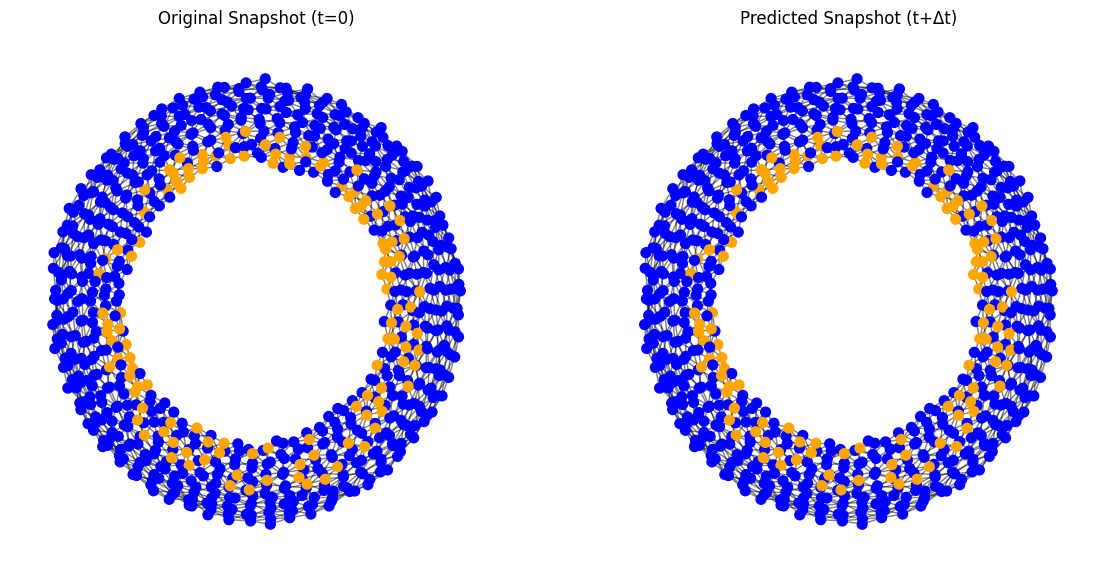

Saved predicted snapshot to output_pickles/simulation_1/predicted_fullgraph_sim1_t_next.pkl


In [84]:
# =========================
# Cell 10: Rollout Prediction and Visualization
# =========================

import os, pickle
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt

# --- Helper function to predict the next snapshot ---
def predict_next_snapshot(gnn_model, regressor, matcher, graph, device):
    """
    Given a graph (from a snapshot dictionary) and the trained model components,
    predict the next snapshot by performing a forward pass on the entire graph.
    
    Returns:
        X_pred: predicted node features (Tensor, shape (N, in_dim))
        node_repr: node embeddings from the GNN backbone
        edge_index: original edge indices (used here for visualization)
    """
    X = torch.FloatTensor(graph.X).to(device)      # shape (N, 12)
    N = X.shape[0]
    node_type = torch.zeros(N, dtype=torch.long).to(device)  # only one type
    edge_index = torch.LongTensor(graph.edge_index).to(device)
    edge_type = torch.FloatTensor(graph.edge_type).to(device)
    edge_time = torch.LongTensor(graph.edge_time).to(device)
    
    # Forward pass through the backbone and regression head.
    node_repr = gnn_model(X, node_type, edge_time, edge_index, edge_type)
    X_pred = regressor(node_repr, original_x=X)  # constant columns are copied
    return X_pred, node_repr, edge_index

# --- Helper function: Build a NetworkX graph from node features and edge_index ---
def build_nx_graph_from_data(X, edge_index):
    """
    Build a NetworkX graph from node features (X) and edge indices.
    The nodes are colored according to the 5th feature of X (index 4).
    
    Args:
        X: numpy array of shape (N, 12)
        edge_index: numpy array of shape (2, E)
    
    Returns:
        G: networkx.Graph object
        colors: list of colors for each node based on feature index 4.
    """
    G = nx.Graph()
    N = X.shape[0]
    # Add nodes with attribute 'f5' equal to the 5th feature.
    for i in range(N):
        G.add_node(i, f5=X[i, 4])
    # Add edges from edge_index.
    E = edge_index.shape[1]
    for j in range(E):
        src = int(edge_index[0, j])
        tgt = int(edge_index[1, j])
        G.add_edge(src, tgt)
    # Determine node colors: for example, blue if feature < 0.5, orange if >= 0.5.
    colors = []
    for i in range(N):
        val = G.nodes[i]['f5']
        colors.append('blue' if val < 0.5 else 'orange')
    return G, colors

# --- Helper function: Plot two graphs side-by-side using Kamada–Kawai layout ---
def plot_original_and_predicted(X_orig, X_pred, edge_index, title_orig="Original Snapshot (t=0)", title_pred="Predicted Snapshot (t+Δt)"):
    """
    Plot the original and predicted graphs side-by-side.
    The node positions are computed using the Kamada–Kawai layout.
    Nodes are colored based on their 5th feature (index 4) from the feature matrix.
    """
    # Build NetworkX graphs for original and predicted features.
    G_orig, colors_orig = build_nx_graph_from_data(X_orig, edge_index)
    G_pred, colors_pred = build_nx_graph_from_data(X_pred, edge_index)
    
    # Compute layouts (Kamada–Kawai layout).
    pos_orig = nx.kamada_kawai_layout(G_orig)
    pos_pred = nx.kamada_kawai_layout(G_pred)
    
    # Create subplots.
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    axs[0].set_title(title_orig)
    axs[1].set_title(title_pred)
    
    # Draw original graph.
    nx.draw_networkx_nodes(G_orig, pos_orig, node_color=colors_orig, node_size=50, ax=axs[0])
    nx.draw_networkx_edges(G_orig, pos_orig, alpha=0.5, ax=axs[0])
    axs[0].axis("off")
    
    # Draw predicted graph.
    nx.draw_networkx_nodes(G_pred, pos_pred, node_color=colors_pred, node_size=50, ax=axs[1])
    nx.draw_networkx_edges(G_pred, pos_pred, alpha=0.5, ax=axs[1])
    axs[1].axis("off")
    
    plt.show()

# ====== Begin: Rollout and Plotting Code ======
def rollout_prediction_and_plot():
    # Load the initial snapshot from the pickle file (t = 0)
    snapshot_file = os.path.join("output_pickles/simulation_1", "fullgraph_sim1_t0.pkl")
    if not os.path.exists(snapshot_file):
        print(f"Snapshot file {snapshot_file} not found.")
        return
    with open(snapshot_file, "rb") as f:
        init_dict = pickle.load(f)
    print(f"Loaded initial snapshot with X shape: {init_dict['X'].shape}")
    
    # Convert dictionary to graph object.
    graph = dict_to_graph(init_dict)
    
    # Predict the next snapshot using the trained model.
    X_pred_tensor, node_repr, edge_index_tensor = predict_next_snapshot(gnn_model, regressor, matcher, graph, device)
    X_pred = X_pred_tensor.cpu().detach().numpy()  # predicted node features
    X_orig = np.array(graph.X)  # original node features from t=0
    edge_index = np.array(graph.edge_index)  # use the original connectivity for plotting
    
    print(f"Predicted X shape: {X_pred.shape}")
    
    # Plot the original and predicted graphs side-by-side.
    plot_original_and_predicted(X_orig, X_pred, edge_index,
                                title_orig="Original Snapshot (t=0)",
                                title_pred="Predicted Snapshot (t+Δt)")
    
    # Optionally, save the predicted snapshot as a new pickle.
    predicted_dict = {
        "X": X_pred,
        "edge_index": edge_index,  # you can also use a new connectivity if computed
        "edge_type": graph.edge_type,  # unchanged for now
        "edge_time": graph.edge_time,  # unchanged for now
        "y": None  # placeholder
    }
    out_file = os.path.join("output_pickles/simulation_1", "predicted_fullgraph_sim1_t_next.pkl")
    with open(out_file, "wb") as f:
        pickle.dump(predicted_dict, f)
    print(f"Saved predicted snapshot to {out_file}")
    
    return predicted_dict

# Run the rollout and plotting function.
outputs_pred = rollout_prediction_and_plot()
# ====== End: Rollout and Plotting Code ======


In [86]:
# =========================
# Cell 10: Rollout Prediction and Visualization over 100 Steps
# (Outputs Kamada–Kawai plots named as {step}.png in directory "test_prediction_plots")
# =========================

import os
import pickle
import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Helper function: Build a NetworkX graph from node features and edge_index.
def build_nx_graph_from_data(X, edge_index):
    """
    Build a NetworkX graph from node features and edge indices.
    Nodes are assigned an attribute 'f5' which is taken from the 5th column of X.
    Colors are determined by the value of the 5th feature (blue if < 0.5, orange if ≥ 0.5).
    """
    G = nx.Graph()
    N = X.shape[0]
    # Add nodes with attribute 'f5'
    for i in range(N):
        G.add_node(i, f5=X[i, 4])
    # Add edges from edge_index (assumed shape (2, E))
    E = edge_index.shape[1]
    for j in range(E):
        src = int(edge_index[0, j])
        tgt = int(edge_index[1, j])
        G.add_edge(src, tgt)
    # Determine node colors based on 'f5'
    colors = []
    for i in range(N):
        val = X[i, 4]
        colors.append('blue' if val < 0.5 else 'orange')
    return G, colors

# Helper function: Predict the next snapshot.
def predict_next_snapshot(gnn_model, regressor, matcher, graph, device):
    """
    Predict the next snapshot using the trained model.
    This function uses the current graph.X (node features) and fixed connectivity from graph.edge_index.
    
    Returns:
      X_pred: Predicted node features (Tensor, shape (N, in_dim))
      node_repr: Node embeddings from the GNN backbone.
      edge_index: The original edge index (unchanged).
    """
    X = torch.FloatTensor(graph.X).to(device)      # shape (N, in_dim)
    N = X.shape[0]
    node_type = torch.zeros(N, dtype=torch.long).to(device)  # one type for all nodes
    edge_index = torch.LongTensor(graph.edge_index).to(device)
    edge_type = torch.FloatTensor(graph.edge_type).to(device)
    edge_time = torch.LongTensor(graph.edge_time).to(device)
    
    node_repr = gnn_model(X, node_type, edge_time, edge_index, edge_type)
    X_pred = regressor(node_repr, original_x=X)
    return X_pred, node_repr, edge_index

# ====== Begin Rollout Predictions ======
def rollout_and_plot_predictions(num_steps=100, out_dir="test_prediction_plots"):
    os.makedirs(out_dir, exist_ok=True)
    
    # Load the initial snapshot (t = 0)
    snapshot_file = os.path.join("output_pickles/simulation_1", "fullgraph_sim1_t0.pkl")
    if not os.path.exists(snapshot_file):
        print(f"Snapshot file {snapshot_file} not found.")
        return
    with open(snapshot_file, "rb") as f:
        init_dict = pickle.load(f)
    print(f"Loaded initial snapshot with X shape: {init_dict['X'].shape}")
    
    # Convert dictionary to graph object using dict_to_graph (from Cell 9)
    graph = dict_to_graph(init_dict)
    
    # Set current node features as the initial ones.
    current_X = torch.FloatTensor(graph.X)
    
    # Use the original connectivity from the graph.
    edge_index = torch.LongTensor(graph.edge_index)
    
    # For each rollout step, predict the next node features and plot.
    for step in range(num_steps):
        # Update the graph's X with the current node features.
        graph.X = current_X.cpu().detach().numpy()
        
        # Predict the next snapshot.
        X_pred, node_repr, _ = predict_next_snapshot(gnn_model, regressor, matcher, graph, device)
        
        # Update current_X for the next iteration.
        current_X = X_pred
        
        # Convert predicted features to numpy array.
        X_np = X_pred.cpu().detach().numpy()
        # Build a NetworkX graph from the predicted node features and the original edge_index.
        G, colors = build_nx_graph_from_data(X_np, edge_index.cpu().detach().numpy())
        
        # Compute the Kamada–Kawai layout.
        pos = nx.kamada_kawai_layout(G)
        
        # Plot the graph.
        plt.figure(figsize=(8, 6))
        nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=100)
        nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.6)
        plt.title(f"Predicted Snapshot at Step {step}")
        plt.axis("off")
        
        # Save the figure.
        out_path = os.path.join(out_dir, f"{step}.png")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"Saved plot for step {step} to {out_path}")
    print("Rollout prediction and plotting complete.")
    return

# ====== End Rollout Predictions ======

# Run the rollout prediction and plotting.
outputs_rollout = rollout_and_plot_predictions(num_steps=100, out_dir="test_prediction_plots")


Loaded initial snapshot with X shape: (840, 12)
Saved plot for step 0 to test_prediction_plots/0.png
Saved plot for step 1 to test_prediction_plots/1.png
Saved plot for step 2 to test_prediction_plots/2.png
Saved plot for step 3 to test_prediction_plots/3.png
Saved plot for step 4 to test_prediction_plots/4.png
Saved plot for step 5 to test_prediction_plots/5.png
Saved plot for step 6 to test_prediction_plots/6.png
Saved plot for step 7 to test_prediction_plots/7.png
Saved plot for step 8 to test_prediction_plots/8.png
Saved plot for step 9 to test_prediction_plots/9.png
Saved plot for step 10 to test_prediction_plots/10.png
Saved plot for step 11 to test_prediction_plots/11.png
Saved plot for step 12 to test_prediction_plots/12.png
Saved plot for step 13 to test_prediction_plots/13.png
Saved plot for step 14 to test_prediction_plots/14.png
Saved plot for step 15 to test_prediction_plots/15.png
Saved plot for step 16 to test_prediction_plots/16.png
Saved plot for step 17 to test_predic

KeyboardInterrupt: 

In [41]:
import os
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_forecast_sequence(forecasts, out_figs_dir="figs_kamada_forecast"):
    """
    Loops through forecast snapshots and plots each graph using a Kamada–Kawai layout.
    
    Args:
        forecasts: List of forecast snapshot dictionaries (each from your rollout forecast).
                   Each snapshot should contain at least the keys:
                   "edge_index" (2 x E array) and "node_type" (1D array with node type for each node).
        out_figs_dir: Directory where the figures will be saved.
    """
    os.makedirs(out_figs_dir, exist_ok=True)
    
    # Define a list of distinct colors (you can extend this list as needed)
    distinct_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
                       "tab:purple", "tab:brown", "tab:pink", "tab:gray",
                       "tab:olive", "tab:cyan"]
    
    for idx, snap in enumerate(forecasts):
        # Build an undirected graph from the forecast snapshot.
        # We assume snap["edge_index"] is a 2 x E numpy array.
        G = nx.Graph()
        # Get the number of nodes from the length of node_type.
        node_types = np.array(snap["node_type"])
        num_nodes = len(node_types)
        # Add nodes with an attribute "ctype" for color coding.
        for i in range(num_nodes):
            G.add_node(i, ctype=int(node_types[i]))
        
        # Add edges from the edge_index.
        edge_index = np.array(snap["edge_index"])  # shape (2, E)
        for e in range(edge_index.shape[1]):
            src = int(edge_index[0, e])
            tgt = int(edge_index[1, e])
            # Optionally, if you want to filter by predicted connectivity (snap["y"]),
            # you can do so here (for example, only add edge if snap["y"][src, tgt] > 0.5).
            G.add_edge(src, tgt)
        
        # Compute the Kamada–Kawai layout.
        pos = nx.kamada_kawai_layout(G)
        # Color nodes based on their "ctype" attribute.
        node_color_indices = [G.nodes[i]['ctype'] for i in G.nodes()]
        node_colors = [distinct_colors[c % len(distinct_colors)] for c in node_color_indices]
        
        plt.figure(figsize=(8, 6))
        nx.draw_networkx(G, pos=pos, node_color=node_colors, with_labels=False,
                         node_size=50, edge_color="gray")
        plt.title(f"Forecasted Graph Snapshot {idx}")
        out_fig = os.path.join(out_figs_dir, f"forecast_graph_{idx}.png")
        plt.savefig(out_fig, dpi=150, bbox_inches="tight")
        print(f"Saved forecast figure {out_fig}")
        plt.close()

# -----------------------------
# Example usage:
# Assume that 'rollout' is a list of forecast snapshots generated from your rollout_forecast() function.
# For example:
#   initial_snapshot = pickle.load(open("output_pickles/simulation_1/fullgraph_sim1_t0.pkl", "rb"))
#   rollout = rollout_forecast(initial_snapshot, num_steps=5)
#
# Then call the plotting function:
plot_forecast_sequence(rollout, out_figs_dir="figs_kamada_forecast")


Saved forecast figure figs_kamada_forecast/forecast_graph_0.png
Saved forecast figure figs_kamada_forecast/forecast_graph_1.png
Saved forecast figure figs_kamada_forecast/forecast_graph_2.png
Saved forecast figure figs_kamada_forecast/forecast_graph_3.png
Saved forecast figure figs_kamada_forecast/forecast_graph_4.png


## Noise / Momentum

In [3]:
# Cell 1: Imports and Basic Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import copy
import time
import numpy as np
import scipy.sparse as sp
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sb
import dill
from functools import partial
import multiprocessing as mp

# PyTorch Geometric imports:
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.nn.inits import glorot, uniform
from torch_geometric.utils import softmax, to_undirected, sparse_mx_to_torch_sparse_tensor


In [4]:
# Cell 2: Relative Temporal Encoding Module
class RelTemporalEncoding(nn.Module):
    """
    Implements a sinusoid-based temporal encoding.
    This module adds a learned projection of a sinusoidal embedding
    (indexed by a discretized timestamp) to the input vector.
    """
    def __init__(self, n_hid, max_len=240, dropout=0.2):
        super(RelTemporalEncoding, self).__init__()
        position = torch.arange(0., max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, n_hid, 2) * -(math.log(10000.0) / n_hid))
        emb = nn.Embedding(max_len, n_hid)
        emb.weight.data[:, 0::2] = torch.sin(position * div_term) / math.sqrt(n_hid)
        emb.weight.data[:, 1::2] = torch.cos(position * div_term) / math.sqrt(n_hid)
        emb.requires_grad = False
        self.emb = emb
        self.lin = nn.Linear(n_hid, n_hid)
    def forward(self, x, t):
        # x: input vector, t: time index (integer tensor)
        return x + self.lin(self.emb(t))


In [5]:
# Cell 3: HGT and DenseHGT Convolution Modules

class HGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(HGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_types = num_types
        self.num_relations = num_relations
        self.total_rel = num_types * num_relations * num_types
        self.n_heads = n_heads
        self.d_k = out_dim // n_heads
        self.sqrt_dk = math.sqrt(self.d_k)
        self.use_norm = use_norm
        self.use_RTE = use_RTE
        self.att = None

        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.skip = nn.Parameter(torch.ones(num_types))
        self.drop = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type,
                              edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        # edge_type is now a continuous tensor, e.g. [0.06, 0.08, ...]
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        
        # Instead of iterating over discrete relation types, process all edges in one pass.
        # Optionally, if you still want to group by source and target node types, you can keep those loops.
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                if tb.sum() == 0:
                    continue
                q_linear = self.q_linears[target_type]
                # Instead of looping over relation types, we assume every edge now carries a continuous value.
                idx = tb  # Using all edges in this subgroup.
                if idx.sum() == 0:
                    continue
                target_node_vec = node_inp_i[idx]
                source_node_vec = node_inp_j[idx]
                if self.use_RTE:
                    source_node_vec = self.emb(source_node_vec, edge_time[idx])
                # Compute query and key matrices.
                q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                # Here, use the continuous edge type value as a scaling factor.
                # For example, assume we use the first candidate relation parameters (index 0).
                scaling = edge_type[idx].unsqueeze(-1).unsqueeze(-1)  # shape: (num_edges, 1, 1)
                # Multiply the candidate relation attention parameters by the continuous scaling factor.
                weighted_relation_att = scaling * self.relation_att[0]  # shape: (num_edges, n_heads, d_k, d_k)
                # We need to apply the relation transformation to the key:
                # Here we perform a batched matrix multiplication.
                # First, reshape weighted_relation_att so that it matches the batch dimensions.
                weighted_relation_att = weighted_relation_att  # assume each edge uses its own scaling
                # Multiply key matrices by weighted relation parameters:
                # To do this properly, we need to iterate or use advanced indexing if the relation parameters vary per edge.
                # For simplicity, assume that all edges use the same candidate (and scaling varies per edge).
                weighted_k = torch.bmm(k_mat.view(-1, self.d_k), 
                                    self.relation_att[0].repeat(k_mat.size(0), 1, 1))  # shape: (num_edges * n_heads, d_k)
                weighted_k = weighted_k.view(-1, self.n_heads, self.d_k)
                # Then compute the attention scores.
                res_att[idx] = (q_mat * weighted_k).sum(dim=-1) * self.relation_pri[0] / self.sqrt_dk
                # Similarly for message passing:
                v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                weighted_relation_msg = scaling * self.relation_msg[0]
                weighted_v = torch.bmm(v_mat.view(-1, self.d_k), 
                                    self.relation_msg[0].repeat(v_mat.size(0), 1, 1))
                weighted_v = weighted_v.view(-1, self.n_heads, self.d_k)
                res_msg[idx] = weighted_v
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        return res.view(-1, self.out_dim)


    def update(self, aggr_out, node_inp, node_type):
        aggr_out = F.gelu(aggr_out)
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx]))
            alpha = torch.sigmoid(self.skip[target_type])
            if self.use_norm:
                res[idx] = self.norms[target_type](trans_out * alpha + node_inp[idx] * (1 - alpha))
            else:
                res[idx] = trans_out * alpha + node_inp[idx] * (1 - alpha)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)

class DenseHGTConv(MessagePassing):
    def __init__(self, in_dim, out_dim, num_types, num_relations, n_heads, dropout=0.2, use_norm=True, use_RTE=True, **kwargs):
        super(DenseHGTConv, self).__init__(node_dim=0, aggr='add', **kwargs)
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.num_types = num_types
        self.num_relations = num_relations
        self.total_rel = num_types * num_relations * num_types
        self.n_heads = n_heads
        self.d_k = out_dim // n_heads
        self.sqrt_dk = math.sqrt(self.d_k)
        self.use_norm = use_norm
        self.use_RTE = use_RTE
        self.att = None
        
        self.k_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.q_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.v_linears = nn.ModuleList([nn.Linear(in_dim, out_dim) for _ in range(num_types)])
        self.a_linears = nn.ModuleList([nn.Linear(out_dim, out_dim) for _ in range(num_types)])
        if use_norm:
            self.norms = nn.ModuleList([nn.LayerNorm(out_dim) for _ in range(num_types)])
        
        self.relation_pri = nn.Parameter(torch.ones(num_relations, n_heads))
        self.relation_att = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.relation_msg = nn.Parameter(torch.Tensor(num_relations, n_heads, self.d_k, self.d_k))
        self.drop = nn.Dropout(dropout)
        
        if self.use_RTE:
            self.emb = RelTemporalEncoding(in_dim)
        
        glorot(self.relation_att)
        glorot(self.relation_msg)
        
        # Extra dense layers:
        self.mid_linear = nn.Linear(out_dim, out_dim * 2)
        self.out_linear = nn.Linear(out_dim * 2, out_dim)
        self.out_norm = nn.LayerNorm(out_dim)
        
    def forward(self, node_inp, node_type, edge_index, edge_type, edge_time):
        return self.propagate(edge_index, node_inp=node_inp, node_type=node_type, edge_type=edge_type, edge_time=edge_time)
    
    def message(self, edge_index_i, node_inp_i, node_inp_j, node_type_i, node_type_j, edge_type, edge_time):
        data_size = edge_index_i.size(0)
        res_att = torch.zeros(data_size, self.n_heads).to(node_inp_i.device)
        res_msg = torch.zeros(data_size, self.n_heads, self.d_k).to(node_inp_i.device)
        for source_type in range(self.num_types):
            sb = (node_type_j == int(source_type))
            k_linear = self.k_linears[source_type]
            v_linear = self.v_linears[source_type]
            for target_type in range(self.num_types):
                tb = (node_type_i == int(target_type)) & sb
                q_linear = self.q_linears[target_type]
                for relation_type in range(self.num_relations):
                    idx = (edge_type == int(relation_type)) & tb
                    if idx.sum() == 0:
                        continue
                    target_node_vec = node_inp_i[idx]
                    source_node_vec = node_inp_j[idx]
                    if self.use_RTE:
                        source_node_vec = self.emb(source_node_vec, edge_time[idx])
                    q_mat = q_linear(target_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = k_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    k_mat = torch.bmm(k_mat.transpose(1, 0), self.relation_att[relation_type]).transpose(1, 0)
                    res_att[idx] = (q_mat * k_mat).sum(dim=-1) * self.relation_pri[relation_type] / self.sqrt_dk
                    v_mat = v_linear(source_node_vec).view(-1, self.n_heads, self.d_k)
                    res_msg[idx] = torch.bmm(v_mat.transpose(1, 0), self.relation_msg[relation_type]).transpose(1, 0)
        self.att = softmax(res_att, edge_index_i)
        res = res_msg * self.att.view(-1, self.n_heads, 1)
        res = res.view(-1, self.out_dim)
        return res
    
    def update(self, aggr_out, node_inp, node_type):
        res = torch.zeros(aggr_out.size(0), self.out_dim).to(node_inp.device)
        for target_type in range(self.num_types):
            idx = (node_type == int(target_type))
            if idx.sum() == 0:
                continue
            trans_out = self.drop(self.a_linears[target_type](aggr_out[idx])) + node_inp[idx]
            if self.use_norm:
                trans_out = self.norms[target_type](trans_out)
            trans_out = self.drop(self.out_linear(F.gelu(self.mid_linear(trans_out)))) + trans_out
            res[idx] = self.out_norm(trans_out)
        return res

    def __repr__(self):
        return '{}(in_dim={}, out_dim={}, num_types={}, num_relations={})'.format(
            self.__class__.__name__, self.in_dim, self.out_dim, self.num_types, self.num_relations)


In [26]:
# Cell 4: GeneralConv Wrapper
class GeneralConv(nn.Module):
    def __init__(self, conv_name, in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm=True, use_RTE=True):
        super(GeneralConv, self).__init__()
        self.conv_name = conv_name
        if self.conv_name == 'hgt':
            self.base_conv = HGTConv(in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm, use_RTE)
        elif self.conv_name == 'dense_hgt':
            self.base_conv = DenseHGTConv(in_hid, out_hid, num_types, num_relations, n_heads, dropout, use_norm, use_RTE)
        elif self.conv_name == 'gcn':
            from torch_geometric.nn import GCNConv
            self.base_conv = GCNConv(in_hid, out_hid)
        elif self.conv_name == 'gat':
            from torch_geometric.nn import GATConv
            self.base_conv = GATConv(in_hid, out_hid // n_heads, heads=n_heads)
    def forward(self, meta_xs, node_type, edge_index, edge_type, edge_time):
        if self.conv_name in ['hgt', 'dense_hgt']:
            return self.base_conv(meta_xs, node_type, edge_index, edge_type, edge_time)
        elif self.conv_name in ['gcn', 'gat']:
            return self.base_conv(meta_xs, edge_index)


In [ ]:
# Cell 5: ForecastHead and GraphForecastingModel

class ForecastHead(nn.Module):
    def __init__(self, n_hid, node_out_dim, edge_out_dim, const_idx=None):
        """
        Args:
            n_hid: hidden dimension from GNN.
            node_out_dim: output dimension for node features (should match input feature dimension).
            edge_out_dim: number of edge feature channels to predict.
            const_idx: list of indices for constant features (these will be copied from input).
        """
        super(ForecastHead, self).__init__()
        self.n_hid = n_hid
        self.node_out_dim = node_out_dim
        self.edge_out_dim = edge_out_dim
        self.const_idx = const_idx
        self.node_linear = nn.Linear(n_hid, node_out_dim)
        # For edge prediction, use an MLP on the concatenation of two node representations.
        self.edge_mlp = nn.Sequential(
            nn.Linear(n_hid * 2, n_hid),
            nn.ReLU(),
            nn.Linear(n_hid, edge_out_dim)
        )
        # For connectivity prediction, a linear layer produces a single logit per edge.
        self.adj_linear = nn.Linear(n_hid * 2, 1)
    
    def forward(self, H, original_x=None):
        # Predict node features.
        X_pred = self.node_linear(H)
        if self.const_idx is not None and original_x is not None:
            X_pred[:, self.const_idx] = original_x[:, self.const_idx]
        # Predict edge features and connectivity from pairwise combinations.
        N = H.size(0)
        H_i = H.unsqueeze(1).expand(-1, N, -1)  # (N, N, n_hid)
        H_j = H.unsqueeze(0).expand(N, -1, -1)  # (N, N, n_hid)
        edge_input = torch.cat([H_i, H_j], dim=-1)  # (N, N, 2*n_hid)
        E_pred = self.edge_mlp(edge_input)  # (N, N, edge_out_dim)
        y_pred = torch.sigmoid(self.adj_linear(edge_input)).squeeze(-1)  # (N, N)
        return {"X_pred": X_pred, "E_pred": E_pred, "y_pred": y_pred}

class GNNForecast(nn.Module):
    def __init__(self, in_dim, n_hid, num_types, num_relations, n_heads, n_layers, dropout=0.2,
                 conv_name='hgt', prev_norm=False, last_norm=False, use_RTE=True):
        """
        Backbone GNN adapted for forecasting.
        """
        super(GNNForecast, self).__init__()
        self.gcs = nn.ModuleList()
        self.num_types = num_types
        self.in_dim = in_dim
        self.n_hid = n_hid
        self.adapt_ws = nn.ModuleList()
        self.drop = nn.Dropout(dropout)
        for t in range(num_types):
            self.adapt_ws.append(nn.Linear(in_dim, n_hid))
        for l in range(n_layers - 1):
            self.gcs.append(GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=prev_norm, use_RTE=use_RTE))
        self.gcs.append(GeneralConv(conv_name, n_hid, n_hid, num_types, num_relations, n_heads, dropout, use_norm=last_norm, use_RTE=use_RTE))
    def forward(self, node_feature, node_type, edge_time, edge_index, edge_type):
        res = torch.zeros(node_feature.size(0), self.n_hid).to(node_feature.device)
        for t_id in range(self.num_types):
            idx = (node_type == int(t_id))
            if idx.sum() == 0:
                continue
            res[idx] = torch.tanh(self.adapt_ws[t_id](node_feature[idx]))
        meta_xs = self.drop(res)
        for gc in self.gcs:
            meta_xs = gc(meta_xs, node_type, edge_index, edge_type, edge_time)
        return meta_xs

class GraphForecastingModel(nn.Module):
    def __init__(self, in_dim, n_hid, num_types, num_relations, n_heads, n_layers, dropout,
                 conv_name, const_idx, node_out_dim, edge_out_dim, prev_norm=False, last_norm=False, use_RTE=True):
        super(GraphForecastingModel, self).__init__()
        self.gnn = GNNForecast(in_dim, n_hid, num_types, num_relations, n_heads, n_layers, dropout,
                               conv_name, prev_norm, last_norm, use_RTE)
        self.forecast_head = ForecastHead(n_hid, node_out_dim, edge_out_dim, const_idx)
    def forward(self, node_feature, node_type, edge_time, edge_index, edge_type, original_x=None):
        H = self.gnn(node_feature, node_type, edge_time, edge_index, edge_type)
        return self.forecast_head(H, original_x)


In [ ]:
# Cell 6: Utility Functions
def dcg_at_k(r, k):
    r = np.asfarray(r)[:k]
    if r.size:
        return r[0] + np.sum(r[1:] / np.log2(np.arange(2, r.size + 1)))
    return 0.

def ndcg_at_k(r, k):
    dcg_max = dcg_at_k(sorted(r, reverse=True), k)
    if not dcg_max:
        return 0.
    return dcg_at_k(r, k) / dcg_max

def mean_reciprocal_rank(rs):
    rs = (np.asarray(r).nonzero()[0] for r in rs)
    return [1. / (r[0] + 1) if r.size else 0. for r in rs]

def normalize(mx):
    """Row-normalize sparse matrix"""
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -1).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    return r_mat_inv.dot(mx)

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def randint():
    return np.random.randint(2**32 - 1)


In [ ]:
# Cell 7: Data Handling and Preprocessing
class Graph():
    def __init__(self):
        super(Graph, self).__init__()
        # These dictionaries store node features and mappings.
        self.node_forward = defaultdict(dict)   # maps node id by type
        self.node_bacward = defaultdict(list)     # list of nodes per type
        self.node_feature = defaultdict(list)      # will store a DataFrame or list of features per type
        # Edge list stored as <target_type, source_type, relation_type, target_id, source_id>
        self.edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(int)))))
        self.times = {}
    def add_node(self, node):
        nfl = self.node_forward[node['type']]
        if node['id'] not in nfl:
            self.node_bacward[node['type']].append(node)
            ser = len(nfl)
            nfl[node['id']] = ser
            return ser
        return nfl[node['id']]
    def add_edge(self, source_node, target_node, time=None, relation_type=None, directed=True):
        edge = [self.add_node(source_node), self.add_node(target_node)]
        self.edge_list[target_node['type']][source_node['type']][relation_type][edge[1]][edge[0]] = time
        if directed:
            self.edge_list[source_node['type']][target_node['type']]['rev_' + relation_type][edge[0]][edge[1]] = time
        else:
            self.edge_list[source_node['type']][target_node['type']][relation_type][edge[0]][edge[1]] = time
        if time is not None:
            self.times[time] = True
    def update_node(self, node):
        nbl = self.node_bacward[node['type']]
        ser = self.add_node(node)
        for k in node:
            if k not in nbl[ser]:
                nbl[ser][k] = node[k]
    def get_meta_graph(self):
        metas = []
        for target_type in self.edge_list:
            for source_type in self.edge_list[target_type]:
                for r_type in self.edge_list[target_type][source_type]:
                    metas.append((target_type, source_type, r_type))
        return metas
    def get_types(self):
        return list(self.node_feature.keys())

def sample_subgraph(graph, time_range, sampled_depth=2, sampled_number=8, inp=None, feature_extractor=None):
    layer_data = defaultdict(dict)
    budget = defaultdict(lambda: defaultdict(lambda: [0., 0]))
    new_layer_adj = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    
    def add_budget(te, target_id, target_time, layer_data, budget):
        for source_type in te:
            tes = te[source_type]
            for relation_type in tes:
                if relation_type == 'self' or target_id not in tes[relation_type]:
                    continue
                adl = tes[relation_type][target_id]
                if len(adl) < sampled_number:
                    sampled_ids = list(adl.keys())
                else:
                    sampled_ids = np.random.choice(list(adl.keys()), sampled_number, replace=False)
                for source_id in sampled_ids:
                    source_time = adl[source_id]
                    if source_time is None:
                        source_time = target_time
                    if source_time > np.max(list(time_range.keys())) or source_id in layer_data[source_type]:
                        continue
                    budget[source_type][source_id][0] += 1. / len(sampled_ids)
                    budget[source_type][source_id][1] = source_time
    
    for _type in inp:
        for _id, _time in inp[_type]:
            layer_data[_type][_id] = [len(layer_data[_type]), _time]
    for _type in inp:
        te = graph.edge_list[_type]
        for _id, _time in inp[_type]:
            add_budget(te, _id, _time, layer_data, budget)
    for layer in range(sampled_depth):
        for source_type in list(budget.keys()):
            keys = np.array(list(budget[source_type].keys()))
            if sampled_number > len(keys):
                sampled_ids = np.arange(len(keys))
            else:
                score = np.array([budget[source_type][k][0] for k in keys]) ** 2
                score = score / np.sum(score)
                sampled_ids = np.random.choice(len(score), sampled_number, p=score, replace=False)
            sampled_keys = keys[sampled_ids]
            for k in sampled_keys:
                layer_data[source_type][k] = [len(layer_data[source_type]), budget[source_type][k][1]]
            te = graph.edge_list[source_type]
            for k in sampled_keys:
                add_budget(te, k, budget[source_type][k][1], layer_data, budget)
                budget[source_type].pop(k)
    feature, times, indxs, texts = feature_extractor(layer_data, graph)
    edge_list = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for _type in layer_data:
        for _key in layer_data[_type]:
            _ser = layer_data[_type][_key][0]
            edge_list[_type][_type]['self'].append([_ser, _ser])
    for target_type in graph.edge_list:
        te = graph.edge_list[target_type]
        tld = layer_data[target_type]
        for source_type in te:
            if source_type not in layer_data: continue
            sld = layer_data[source_type]
            for relation_type in te[source_type]:
                tesr = te[source_type][relation_type]
                for target_key in tld:
                    if target_key not in tesr:
                        continue
                    target_ser = tld[target_key][0]
                    for source_key in tesr[target_key]:
                        if source_key in sld:
                            source_ser = sld[source_key][0]
                            edge_list[target_type][source_type][relation_type].append([target_ser, source_ser])
    return feature, times, edge_list, indxs, texts

def to_torch(feature, time, edge_list, graph):
    node_dict = {}
    node_feature = []
    node_type = []
    node_time = []
    edge_index = []
    edge_type = []
    edge_time = []
    
    node_num = 0
    types = graph.get_types()
    for t in types:
        node_dict[t] = [node_num, len(node_dict)]
        node_num += len(feature[t])
    for t in types:
        node_feature += list(feature[t])
        node_time += list(time[t])
        node_type += [node_dict[t][1]] * len(feature[t])
    edge_dict = {e[2]: i for i, e in enumerate(graph.get_meta_graph())}
    edge_dict['self'] = len(edge_dict)
    for target_type in edge_list:
        for source_type in edge_list[target_type]:
            for relation_type in edge_list[target_type][source_type]:
                for ti, si in edge_list[target_type][source_type][relation_type]:
                    tid = ti + node_dict[target_type][0]
                    sid = si + node_dict[source_type][0]
                    edge_index.append([sid, tid])
                    edge_type.append(edge_dict[relation_type])
                    edge_time.append(node_time[tid] - node_time[sid] + 120)
    node_feature = torch.FloatTensor(node_feature)
    node_type = torch.LongTensor(node_type)
    edge_time = torch.LongTensor(edge_time)
    edge_index = torch.LongTensor(edge_index).t()
    edge_type = torch.LongTensor(edge_type)
    return node_feature, node_type, edge_time, edge_index, edge_type, node_dict, edge_dict

def feature_OAG(layer_data, graph):
    feature = {}
    times = {}
    indxs = {}
    texts = []
    for _type in layer_data:
        if len(layer_data[_type]) == 0:
            continue
        idxs = np.array(list(layer_data[_type].keys()))
        tims = np.array([layer_data[_type][k][1] for k in idxs])
        if 'node_emb' in graph.node_feature[_type]:
            feature[_type] = np.array(list(graph.node_feature[_type].loc[idxs, 'node_emb']), dtype=np.float)
        else:
            feature[_type] = np.zeros([len(idxs), 400])
        feature[_type] = np.concatenate((feature[_type],
                                         list(graph.node_feature[_type].loc[idxs, 'emb']),
                                         np.log10(np.array(list(graph.node_feature[_type].loc[idxs, 'citation'])).reshape(-1, 1) + 0.01)),
                                        axis=1)
        times[_type] = tims
        indxs[_type] = idxs
        if _type == 'paper':
            texts = np.array(list(graph.node_feature[_type].loc[idxs, 'title']), dtype=str)
    return feature, times, indxs, texts

class RenameUnpickler(dill.Unpickler):
    def find_class(self, module, name):
        renamed_module = module
        if module == "GPT_GNN.data" or module == 'data':
            renamed_module = "pyHGT.data"
        return super(RenameUnpickler, self).find_class(renamed_module, name)

def renamed_load(file_obj):
    return RenameUnpickler(file_obj).load()


In [ ]:
# Cell 8: Data Sampling Functions
def ogbn_sample(seed, samp_nodes):
    np.random.seed(seed)
    ylabel = torch.LongTensor(graph.y[samp_nodes])
    feature, times, edge_list, indxs, _ = sample_subgraph(
        graph,
        time_range={t: True for t in graph.times},
        inp={'paper': np.concatenate([samp_nodes, graph.years[samp_nodes]]).reshape(2, -1).transpose()},
        sampled_depth=args.sample_depth,
        sampled_number=args.sample_width,
        feature_extractor=feature_OAG
    )
    node_feature, node_type, edge_time, edge_index, edge_type, node_dict, edge_dict = to_torch(feature, times, edge_list, graph)
    train_mask = graph.train_mask[indxs['paper']]
    valid_mask = graph.valid_mask[indxs['paper']]
    test_mask = graph.test_mask[indxs['paper']]
    ylabel = graph.y[indxs['paper']]
    return node_feature, node_type, edge_time, edge_index, edge_type, (train_mask, valid_mask, test_mask), ylabel

def prepare_data(pool, task_type='train', s_idx=0, n_batch=args.n_batch, batch_size=args.batch_size):
    jobs = []
    if task_type == 'train':
        for _ in range(n_batch):
            p = pool.apply_async(ogbn_sample, args=([randint(), np.random.choice(target_nodes, args.batch_size, replace=False)]))
            jobs.append(p)
    elif task_type == 'sequential':
        for i in range(n_batch):
            target_papers = graph.test_paper[(s_idx + i) * batch_size : (s_idx + i + 1) * batch_size]
            p = pool.apply_async(ogbn_sample, args=([randint(), target_papers]))
            jobs.append(p)
    elif task_type == 'variance_reduce':
        target_papers = graph.test_paper[s_idx * args.batch_size : (s_idx + 1) * args.batch_size]
        for _ in range(n_batch):
            p = pool.apply_async(ogbn_sample, args=([randint(), target_papers]))
            jobs.append(p)
    return jobs


In [ ]:
# Cell 9: Main Training/Evaluation and Argument Parsing

import argparse
from ogb.nodeproppred import Evaluator

parser = argparse.ArgumentParser(description='Training GNN for Graph Forecasting')
parser.add_argument('--data_dir', type=str, default='/datadrive/dataset/OGB_MAG.pk',
                    help='Address of preprocessed graph pickle file.')
parser.add_argument('--model_dir', type=str, default='./hgt_forecast_model.pt',
                    help='Path to save/load the trained model.')
parser.add_argument('--task_type', type=str, default='variance_reduce',
                    help='Task type: variance_reduce, sequential, or train')
parser.add_argument('--vr_num', type=int, default=8,
                    help='Samples for variance reduction evaluation')
parser.add_argument('--n_pool', type=int, default=8,
                    help='Number of processes for subgraph sampling')
parser.add_argument('--n_batch', type=int, default=32,
                    help='Number of batches per epoch')
parser.add_argument('--batch_size', type=int, default=128,
                    help='Batch size (number of output nodes for training)')
parser.add_argument('--conv_name', type=str, default='hgt',
                    choices=['hgt', 'gcn', 'gat', 'rgcn', 'han', 'hetgnn'],
                    help='Name of the GNN convolution type')
parser.add_argument('--n_hid', type=int, default=512,
                    help='Hidden dimension')
parser.add_argument('--n_heads', type=int, default=8,
                    help='Number of attention heads')
parser.add_argument('--n_layers', type=int, default=4,
                    help='Number of GNN layers')
parser.add_argument('--dropout', type=float, default=0.2,
                    help='Dropout ratio')
parser.add_argument('--sample_depth', type=int, default=6,
                    help='Depth to sample subgraph')
parser.add_argument('--sample_width', type=int, default=520,
                    help='Number of nodes sampled per layer per type')
parser.add_argument('--n_epoch', type=int, default=100,
                    help='Number of training epochs')
parser.add_argument('--clip', type=float, default=1.0,
                    help='Gradient clipping norm')
parser.add_argument('--prev_norm', action='store_true', help='Apply layer norm on previous layers')
parser.add_argument('--last_norm', action='store_true', help='Apply layer norm on the last layer')
parser.add_argument('--use_RTE', action='store_true', help='Use Relative Temporal Encoding')
parser.add_argument('--cuda', type=int, default=0, help='CUDA device id')

args = parser.parse_args()
print(args)

# Load graph from pickle.
graph = dill.load(open(args.data_dir, 'rb'))
target_nodes = np.arange(len(graph.node_feature['paper']))

evaluator = Evaluator(name='ogbn-mag')
device = torch.device("cuda:%d" % args.cuda)

# Define which columns in node features are constant.
# For example, assume that columns 8 and onward are constant.
const_indices = list(range(8, len(graph.node_feature['paper'][0])))
node_out_dim = len(graph.node_feature['paper'][0])
edge_out_dim = 2  # for example, predicting two edge feature channels

# Initialize the forecasting model.
model = GraphForecastingModel(
    in_dim = len(graph.node_feature['paper'][0]),
    n_hid = args.n_hid,
    num_types = len(graph.get_types()),
    num_relations = len(graph.get_meta_graph()) + 1,  # add one for self-loop
    n_heads = args.n_heads,
    n_layers = args.n_layers,
    dropout = args.dropout,
    conv_name = args.conv_name,
    const_idx = const_indices,
    node_out_dim = node_out_dim,
    edge_out_dim = edge_out_dim,
    prev_norm = args.prev_norm,
    last_norm = args.last_norm,
    use_RTE = args.use_RTE
).to(device)

print('Model #Params: %d' % sum(p.numel() for p in model.parameters()))

# For forecasting, use MSELoss for node feature prediction.
criterion = nn.MSELoss()

param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters, eps=1e-06)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, pct_start=0.05, anneal_strategy='linear', final_div_factor=10,
    max_lr=5e-4, total_steps=args.n_batch * args.n_epoch + 1
)

# (Optionally: Save a best model based on validation loss.)

pool = mp.Pool(args.n_pool)
jobs = prepare_data(pool)

stats = []
train_step = 0

for epoch in range(1, args.n_epoch + 1):
    datas = [job.get() for job in jobs]
    pool.close()
    pool.join()
    pool = mp.Pool(args.n_pool)
    jobs = prepare_data(pool)
    epoch_start = time.time()
    model.train()
    stat = []
    for (node_feature, node_type, edge_time, edge_index, edge_type, 
         (train_mask, valid_mask, test_mask), ylabel) in datas:
        # In forecasting, node_feature is at time t.
        # Here, ylabel represents the ground truth node features at time t+1.
        output = model(node_feature.to(device), node_type.to(device),
                       edge_time.to(device), edge_index.to(device), edge_type.to(device),
                       original_x=node_feature.to(device))
        # Forecasting outputs is a dictionary with keys: "X_pred", "E_pred", "y_pred"
        X_pred = output["X_pred"]
        # Compute loss only on variable node features.
        loss = criterion(X_pred[:, :8], torch.FloatTensor(ylabel).to(device)[:, :8])
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), args.clip)
        optimizer.step()
        train_step += 1
        scheduler.step(train_step)
        stat.append([loss.item()])
    stats.append(stat)
    avgs = np.average(stat, axis=0)
    print(f'Epoch: {epoch} LR: {optimizer.param_groups[0]["lr"]:.5f} Loss: {avgs[0]:.4f}')


In [ ]:
# Cell 10: Rollout Forecasting (Optional)
def rollout_forecast(initial_snapshot, num_steps):
    """
    Given an initial snapshot (dictionary with keys "X", "E", "y", etc.),
    repeatedly apply the model to forecast the graph at subsequent timepoints.
    
    Args:
        initial_snapshot: a dictionary loaded from a pickle file at time t.
        num_steps: number of time steps to rollout.
        
    Returns:
        A list of forecasted snapshots.
    """
    forecasts = []
    current_snapshot = initial_snapshot
    for step in range(num_steps):
        # Convert current snapshot to torch inputs.
        # Here, we assume current_snapshot contains keys: "X", "node_type", "edge_index", "edge_type", "edge_time".
        X = torch.FloatTensor(current_snapshot["X"])
        node_type = torch.LongTensor(current_snapshot["node_type"])
        edge_index = torch.LongTensor(current_snapshot["edge_index"])
        edge_type = torch.LongTensor(current_snapshot["edge_type"])
        edge_time = torch.LongTensor(current_snapshot["edge_time"])
        # Run forecasting model.
        model.eval()
        with torch.no_grad():
            output = model(X.to(device), node_type.to(device),
                           edge_time.to(device), edge_index.to(device), edge_type.to(device),
                           original_x=X.to(device))
        # Collect predictions.
        forecast = {
            "X": output["X_pred"].cpu().numpy(),  # forecasted node features
            "E": output["E_pred"].cpu().numpy(),  # forecasted edge features
            "y": output["y_pred"].cpu().numpy(),    # forecasted connectivity (adjacency)
            "node_type": current_snapshot["node_type"],
            "edge_index": current_snapshot["edge_index"],
            "edge_type": current_snapshot["edge_type"],
            "edge_time": current_snapshot["edge_time"]
        }
        forecasts.append(forecast)
        # For the next time step, assume you update the variable features with the predicted ones.
        # Here, you might want to copy constant features from current_snapshot["X"] if needed.
        # For simplicity, we set the next input X to the forecasted X_pred.
        current_snapshot["X"] = forecast["X"]
    return forecasts

# Example usage:
# initial_snapshot = pickle.load(open("output_pickles/simulation_1/fullgraph_sim1_t1000.pkl", "rb"))
# forecasts = rollout_forecast(initial_snapshot, num_steps=10)
# (You can then compare these forecasts with the actual snapshots.)


## Prediction

In [75]:
# import os
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import pickle

# ###############################################################################
# # Placeholder: The same CENDGCNN you used in training. 
# # Must match node_dim=12, edge_dim=2, etc. for shape consistency.
# ###############################################################################
# class IdentityMapping(nn.Module):
#     def __init__(self, in_dim, out_dim, layer_idx, max_layers=64):
#         super().__init__()
#         self.in_dim = in_dim
#         self.out_dim = out_dim
#         self.layer_idx = layer_idx
#         self.max_layers = max_layers

#         self.W = nn.Parameter(torch.Tensor(out_dim, in_dim))
#         nn.init.xavier_uniform_(self.W)

#     def forward(self, X):
#         l = max(self.layer_idx, 1)
#         delta_l = torch.log(torch.tensor(0.5 + float(l))) / float(l)

#         if self.in_dim != self.out_dim:
#             # fallback
#             return X @ self.W.transpose(0,1)

#         X_linear = X @ self.W.transpose(0,1)
#         return (1.0 - delta_l)*X + delta_l*X_linear


# class CENDGCNNLayer(nn.Module):
#     def __init__(self, node_dim=12, edge_dim=2, layer_idx=1, max_layers=64):
#         super().__init__()
#         self.node_dim = node_dim
#         self.edge_dim = edge_dim

#         self.W_nodes = nn.Parameter(torch.Tensor(node_dim, node_dim))
#         nn.init.xavier_uniform_(self.W_nodes)

#         self.a = nn.Parameter(torch.Tensor(node_dim*2 + edge_dim, 1))
#         nn.init.xavier_uniform_(self.a)

#         self.zeta = nn.Parameter(torch.tensor(0.3))
#         self.eta  = nn.Parameter(torch.tensor(0.3))
#         self.theta= nn.Parameter(torch.tensor(0.4))

#         self.layer_idx = layer_idx
#         self.identity_map = IdentityMapping(node_dim, node_dim, layer_idx, max_layers)

#     def forward(self, X_prev, X_init, E_prev):
#         device = X_prev.device
#         N = X_prev.size(0)

#         WX = X_prev @ self.W_nodes.transpose(0,1)

#         i_idx = torch.arange(N, device=device).unsqueeze(1).expand(N,N).reshape(-1)
#         j_idx = torch.arange(N, device=device).unsqueeze(0).expand(N,N).reshape(-1)

#         WX_i  = WX[i_idx]
#         WX_j  = WX[j_idx]
#         E_ij  = E_prev[i_idx, j_idx, :]

#         cat_ij = torch.cat([WX_i, WX_j, E_ij], dim=1)
#         e_ij = F.leaky_relu(cat_ij @ self.a, negative_slope=0.2).view(N, N)

#         alpha_raw = torch.exp(e_ij)
#         row_sum = alpha_raw.sum(dim=1, keepdim=True) + 1e-9
#         alpha = alpha_raw / row_sum

#         alpha3 = alpha.unsqueeze(-1)
#         E_temp = alpha3 * E_prev

#         # simple double-stochastic no-grad. 
#         with torch.no_grad():
#             out_ = E_temp.clone()
#             for _p in range(self.edge_dim):
#                 for _ in range(2):
#                     # row normal
#                     rsum = out_[:,:,_p].sum(dim=1, keepdim=True) + 1e-9
#                     out_[:,:,_p] = out_[:,:,_p] / rsum
#                     # col normal
#                     csum = out_[:,:,_p].sum(dim=0, keepdim=True) + 1e-9
#                     out_[:,:,_p] = out_[:,:,_p] / csum
#         E_out = out_

#         # Node aggregator
#         msg = torch.zeros_like(X_prev)
#         for p in range(self.edge_dim):
#             msg += E_out[:,:,p] @ X_prev

#         aggregator = self.zeta * X_init + self.eta * X_prev + self.theta * msg
#         aggregator_trans = self.identity_map(aggregator)
#         X_out = F.relu(aggregator_trans)
#         return X_out, E_out


# class CENDGCNN(nn.Module):
#     def __init__(self, num_layers=4, node_dim=12, edge_dim=2):
#         super().__init__()
#         self.num_layers = num_layers
#         self.node_dim = node_dim
#         self.edge_dim = edge_dim

#         layers = []
#         for l in range(num_layers):
#             layer = CENDGCNNLayer(node_dim=node_dim,
#                                   edge_dim=edge_dim,
#                                   layer_idx=(l+1),
#                                   max_layers=num_layers)
#             layers.append(layer)
#         self.layers = nn.ModuleList(layers)

#     def forward(self, X_in, E_in):
#         X_init = X_in
#         X_prev = X_in
#         E_prev = E_in
#         for layer in self.layers:
#             X_out, E_out = layer(X_prev, X_init, E_prev)
#             X_prev = X_out
#             E_prev = E_out
#         return X_out, E_out


# ###############################################################################
# # 2) Placeholder param loading
# ###############################################################################
# def load_params(py_path):
#     # same logic as your training code
#     import importlib.util
#     spec = importlib.util.spec_from_file_location("param_module", py_path)
#     param_module = importlib.util.module_from_spec(spec)
#     spec.loader.exec_module(param_module)
#     p = {
#         "v0": getattr(param_module, "v0", None),
#         "W": getattr(param_module, "W", None),
#         "A0": getattr(param_module, "A0", None),
#         "P0": getattr(param_module, "P0", None),
#         "Dr": getattr(param_module, "Dr", None),
#         "kappa_A": getattr(param_module, "kappa_A", None),
#         "kappa_P": getattr(param_module, "kappa_P", None),
#         "a": getattr(param_module, "a", None),
#         "k": getattr(param_module, "k", None),
#     }
#     return p

# ###############################################################################
# # 3) Convert from data_dict => (X_in, E_in) EXACT same as training
# ###############################################################################
# def build_XE_from_data_dict(data_dict, param_dict):
#     """
#     Convert a dictionary { "cell_x", "cell_type", "area", "perimeter", "cell_adj", ... }
#     into (X_in, E_in) for the CEN-DGCNN. 
#     """
#     cell_x    = data_dict["cell_x"]
#     cell_type = data_dict["cell_type"]
#     area      = data_dict["area"]
#     perimeter = data_dict["perimeter"]
#     cell_adj  = data_dict["cell_adj"]
#     voronoi_len = data_dict.get("edge_voronoi_length", None)

#     n_c = cell_x.shape[0]
#     node_feats = []
#     for i in range(n_c):
#         ctype = cell_type[i]
#         A0_val = param_dict["A0"][ctype]
#         P0_val = param_dict["P0"][ctype]
#         (x_i, y_i) = cell_x[i]
#         feats = [
#             x_i,
#             y_i,
#             area[i],
#             perimeter[i],
#             float(ctype),
#             A0_val,
#             P0_val,
#             param_dict["Dr"],
#             param_dict["kappa_A"],
#             param_dict["kappa_P"],
#             param_dict["a"],
#             param_dict["k"],
#         ]
#         node_feats.append(feats)
#     X_in = np.array(node_feats, dtype=np.float32)  # shape [N, 12]

#     # Build edge feats
#     P = 2
#     E_in = np.zeros((n_c, n_c, P), dtype=np.float32)
#     for i in range(n_c):
#         for j in range(n_c):
#             if i != j and cell_adj[i, j] == 1:
#                 vlen = 0.0
#                 if voronoi_len is not None:
#                     vlen = voronoi_len[i, j]
#                 Wij = param_dict["W"][cell_type[i]][cell_type[j]]
#                 E_in[i, j, 0] = vlen
#                 E_in[i, j, 1] = Wij
#     return X_in, E_in

# ###############################################################################
# # 4) Build a new data_dict from (X_out, E_out).
# #    PLACEHOLDER: You must define how you interpret the predicted features.
# ###############################################################################
# def build_data_dict_from_XE(X_out, E_out, old_data_dict, adjacency_threshold=0.1):
#     """
#     We interpret X_out[:,0:2] as new positions, 
#     keep 'cell_type', 'area', 'perimeter' the same, 
#     and produce adjacency by thresholding E_out's 2nd channel if > adjacency_threshold.
#     """
#     new_data_dict = {}
#     X_out_np = X_out.detach().cpu().numpy()
#     E_out_np = E_out.detach().cpu().numpy()

#     N = X_out_np.shape[0]
#     # interpret columns 0..1 as new (x,y)
#     cell_x_new = X_out_np[:, :2]

#     # keep old cell_type, area, perimeter, etc.
#     cell_type_old = old_data_dict["cell_type"]
#     area_old = old_data_dict["area"]
#     perimeter_old = old_data_dict["perimeter"]
#     # Possibly recalc them if your model predicts them, 
#     # but for now we keep them the same.

#     # adjacency by thresholding E_out's 2nd channel
#     interaction_map = E_out_np[:,:,1]  # shape [N,N]
#     adj_new = (interaction_map > adjacency_threshold).astype(np.int32)

#     new_data_dict["cell_x"] = cell_x_new
#     new_data_dict["cell_type"] = cell_type_old
#     new_data_dict["area"] = area_old
#     new_data_dict["perimeter"] = perimeter_old
#     new_data_dict["cell_adj"] = adj_new

#     # keep or override other fields 
#     new_data_dict["edge_voronoi_length"] = old_data_dict.get("edge_voronoi_length", None)
#     new_data_dict["voronoi_nodes"] = old_data_dict.get("voronoi_nodes", None)

#     return new_data_dict

# ###############################################################################
# # 5) The Rollout Prediction Function with Debug Statements
# ###############################################################################
# def rollout_prediction(
#     model_path: str,
#     param_path: str,
#     init_data_path: str,
#     output_dir: str,
#     t_start: int = 0,
#     t_end: int = 10,
#     t_step: int = 1,
#     adjacency_threshold: float = 0.1,
#     device: str = "cpu"
# ):
#     """
#     1) Load the trained model + param file
#     2) Load an initial data_{t_start}.npy
#     3) For t in [t_start, ..., t_end-1], do:
#        - Build (X_in, E_in)
#        - Forward pass => (X_out, E_out)
#        - Interpret => data_dict_next
#        - Save => data_{t + t_step}.npy
#     """
#     # A) Load parameters + model
#     param_dict = load_params(param_path)
#     node_dim = 12
#     edge_dim = 2
#     num_layers = 4

#     model = CENDGCNN(num_layers=num_layers, node_dim=node_dim, edge_dim=edge_dim)
#     model.load_state_dict(torch.load(model_path, map_location=device))
#     model.to(device)
#     model.eval()

#     # B) Load initial data
#     if not os.path.exists(init_data_path):
#         print(f"[ERROR] init_data_path {init_data_path} not found.")
#         return
#     init_data_dict = np.load(init_data_path, allow_pickle=True).item()

#     os.makedirs(output_dir, exist_ok=True)

#     # Optionally save the initial snapshot
#     np.save(os.path.join(output_dir, f"data_{t_start}.npy"), init_data_dict, allow_pickle=True)
#     print(f"Saved initial data_{t_start}.npy in {output_dir}")

#     data_dict_curr = init_data_dict

#     # C) Rollout Loop
#     for t in range(t_start, t_end, t_step):
#         X_np, E_np = build_XE_from_data_dict(data_dict_curr, param_dict)

#         # Debug prints for shapes
#         print(f"\n[rollout] t={t}: X_np shape={X_np.shape}, E_np shape={E_np.shape}")

#         X_in_t = torch.from_numpy(X_np).float().to(device)
#         E_in_t = torch.from_numpy(E_np).float().to(device)

#         with torch.no_grad():
#             X_out, E_out = model(X_in_t, E_in_t)

#         # Another debug: shapes + stats
#         print(f"   -> X_out shape={X_out.shape}, E_out shape={E_out.shape}")
#         print(f"   -> X_out stats: min={X_out.min():.4f}, max={X_out.max():.4f}, mean={X_out.mean():.4f}")
#         print(f"   -> E_out stats: min={E_out.min():.4f}, max={E_out.max():.4f}, mean={E_out.mean():.4f}")

#         data_dict_next = build_data_dict_from_XE(
#             X_out, E_out, data_dict_curr, adjacency_threshold=adjacency_threshold
#         )

#         next_t = t + t_step
#         out_path = os.path.join(output_dir, f"data_{next_t}.npy")
#         np.save(out_path, data_dict_next, allow_pickle=True)
#         print(f"[rollout] Saved predicted data_{next_t}.npy in {output_dir}")

#         # Update for next iteration
#         data_dict_curr = data_dict_next



# # ---------------------------------------------------------------------------

# if __name__ == "__main__":
#     # Suppose:
#     model_path     = "cen_dgcnn_model.pth"  # your trained model
#     param_path     = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/parameters_DPAC1.py"         # same param file used in training
#     init_data_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/validation_Fig5I/parameters_DPAC1_test/data_0.npy"        # initial timepoint 0
#     output_dir     = "predicted_sequence"
#     t_start        = 0
#     t_end          = 2000
#     t_step         = 4
#     device         = "cpu"  # or "cuda"

#     rollout_prediction(
#         model_path=model_path,
#         param_path=param_path,
#         init_data_path=init_data_path,
#         output_dir=output_dir,
#         t_start=t_start,
#         t_end=t_end,
#         t_step=t_step,
#         device=device
#     )


[ERROR] init_data_path /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/validation_Fig5I/parameters_DPAC1_test/data_0.npy not found.


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_35235/1458704939.py:274: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path

## Prediction

In [19]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

###############################################################################
# 1) Data Loading - Same as Before, No Changes
###############################################################################
def build_sequential_dataset(data_dir):
    """
    Reads all *.pkl files in data_dir, each containing a single dictionary:
      {"X": np.ndarray, "E": np.ndarray, "y": np.ndarray or None}.
    Returns a dict: { sim_id: [ (time_id, sample_dict), ... ], ... }.
    """
    all_files = [f for f in os.listdir(data_dir) if f.endswith(".pkl")]
    seq_dataset = {}

    for fname in all_files:
        base = os.path.splitext(fname)[0]
        leftover = base.replace("fullgraph_sim", "")
        parts = leftover.split("_t")
        sim_id = int(parts[0])
        time_id = int(parts[1])
        path = os.path.join(data_dir, fname)

        with open(path, "rb") as f:
            sample_dict = pickle.load(f)

        if sim_id not in seq_dataset:
            seq_dataset[sim_id] = []
        seq_dataset[sim_id].append((time_id, sample_dict))

    # Sort by time_id
    for sim_id in seq_dataset.keys():
        seq_dataset[sim_id].sort(key=lambda x: x[0])
    return seq_dataset

###############################################################################
# 2) Double Stochastic Normalization - No Functional Change
###############################################################################
def double_stochastic_normalization(E, num_iters=2, epsilon=1e-9):
    """
    E: a Tensor of shape [N, N, P]
       - N = number of nodes
       - P = number of edge feature channels

    Applies row->column->row->column normalization on each channel.
    """
    with torch.no_grad():
        out = E.clone()  # avoid in-place modifications
        N, _, P = out.shape

        for p in range(P):
            for _ in range(num_iters):
                row_sum = out[..., p].sum(dim=1, keepdim=True) + epsilon
                out[..., p] = out[..., p] / row_sum
                col_sum = out[..., p].sum(dim=0, keepdim=True) + epsilon
                out[..., p] = out[..., p] / col_sum
    return out

###############################################################################
# 3) Identity Mapping, CENDGCNNLayer, CENDGCNN Classes - (Same as in training)
###############################################################################
class IdentityMapping(nn.Module):
    """ Identity mapping with an adaptive weight. """
    def __init__(self, in_dim, out_dim, layer_idx, max_layers=64):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.layer_idx = layer_idx
        self.max_layers = max_layers
        self.W = nn.Parameter(torch.Tensor(out_dim, in_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, X):
        l = max(self.layer_idx, 1)
        delta_l = torch.log(torch.tensor(0.5 + float(l))) / float(l)
        if self.in_dim != self.out_dim:
            return X @ self.W.transpose(0,1)
        X_linear = X @ self.W.transpose(0,1)
        return (1.0 - delta_l)*X + delta_l*X_linear

class CENDGCNNLayer(nn.Module):
    def __init__(self, node_dim=12, edge_dim=2, layer_idx=1, max_layers=64):
        super().__init__()
        self.node_dim = node_dim
        self.edge_dim = edge_dim

        self.W_nodes = nn.Parameter(torch.Tensor(node_dim, node_dim))
        nn.init.xavier_uniform_(self.W_nodes)

        self.a = nn.Parameter(torch.Tensor(node_dim*2 + edge_dim, 1))
        nn.init.xavier_uniform_(self.a)

        self.zeta = nn.Parameter(torch.tensor(0.3))
        self.eta  = nn.Parameter(torch.tensor(0.3))
        self.theta= nn.Parameter(torch.tensor(0.4))

        self.layer_idx = layer_idx
        self.identity_map = IdentityMapping(node_dim, node_dim, layer_idx, max_layers)

    def forward(self, X_prev, X_init, E_prev):
        N = X_prev.size(0)
        device = X_prev.device

        WX = X_prev @ self.W_nodes.transpose(0,1)  # [N, node_dim]
        i_idx = torch.arange(N, device=device).unsqueeze(1).expand(N, N).reshape(-1)
        j_idx = torch.arange(N, device=device).unsqueeze(0).expand(N, N).reshape(-1)
        WX_i = WX[i_idx]
        WX_j = WX[j_idx]
        E_ij = E_prev[i_idx, j_idx, :]

        cat_ij = torch.cat([WX_i, WX_j, E_ij], dim=1)
        e_ij = F.leaky_relu(cat_ij @ self.a, negative_slope=0.2).view(N, N)
        alpha_raw = torch.exp(e_ij)
        row_sum = alpha_raw.sum(dim=1, keepdim=True) + 1e-9
        alpha = alpha_raw / row_sum

        alpha3 = alpha.unsqueeze(-1)
        E_temp = alpha3 * E_prev
        E_out = double_stochastic_normalization(E_temp)  # [N, N, edge_dim]

        msg = torch.zeros_like(X_prev)
        for p in range(self.edge_dim):
            msg += E_out[:, :, p] @ X_prev

        aggregator = self.zeta * X_init + self.eta * X_prev + self.theta * msg
        aggregator_trans = self.identity_map(aggregator)
        X_out = F.relu(aggregator_trans)
        return X_out, E_out

class CENDGCNN(nn.Module):
    def __init__(self, num_layers=4, node_dim=12, edge_dim=2):
        super().__init__()
        self.num_layers = num_layers
        self.node_dim = node_dim
        self.edge_dim = edge_dim

        layers = []
        for l in range(num_layers):
            layers.append(CENDGCNNLayer(node_dim=node_dim,
                                         edge_dim=edge_dim,
                                         layer_idx=l+1,
                                         max_layers=num_layers))
        self.layers = nn.ModuleList(layers)
        # The second channel of E_out is used for adjacency prediction.
        self.adj_pred_layer = nn.Linear(1, 1)

    def forward(self, X_in, E_in):
        X_init = X_in
        X_prev = X_in
        E_prev = E_in
        for layer in self.layers:
            X_out, E_out = layer(X_prev, X_init, E_prev)
            X_prev = X_out
            E_prev = E_out
        # Predict adjacency using channel 1 (without sigmoid)
        E_adj = E_out[:, :, 1].unsqueeze(-1)
        E_adj = self.adj_pred_layer(E_adj).squeeze(-1)
        return X_out, E_out, E_adj

###############################################################################
# 4) Updated build_data_dict_from_XE
###############################################################################
def build_data_dict_from_XE(X_out, E_out, E_adj, old_data_dict, adjacency_threshold=0.1):
    """
    Converts model outputs into a data dictionary.
    - Interprets X_out[:,0:2] as new positions.
    - Keeps old cell_type, area, and perimeter.
    - Uses the predicted adjacency E_adj (after thresholding) as new cell_adj.
    """
    new_data_dict = {}
    X_out_np = X_out.detach().cpu().numpy()
    E_adj_np = E_adj.detach().cpu().numpy()

    N = X_out_np.shape[0]
    cell_x_new = X_out_np[:, :2]

    cell_type_old = old_data_dict["cell_type"]
    area_old = old_data_dict["area"]
    perimeter_old = old_data_dict["perimeter"]

    # Create new adjacency by thresholding the predicted adjacency logits.
    adj_new = (E_adj_np > adjacency_threshold).astype(np.int32)

    new_data_dict["cell_x"] = cell_x_new
    new_data_dict["cell_type"] = cell_type_old
    new_data_dict["area"] = area_old
    new_data_dict["perimeter"] = perimeter_old
    new_data_dict["cell_adj"] = adj_new

    # Preserve other fields if present.
    new_data_dict["edge_voronoi_length"] = old_data_dict.get("edge_voronoi_length", None)
    new_data_dict["voronoi_nodes"] = old_data_dict.get("voronoi_nodes", None)
    return new_data_dict

###############################################################################
# 5) Rollout Prediction Function with Updated Model Outputs
###############################################################################
def rollout_prediction(
    model_path: str,
    param_path: str,
    init_data_path: str,
    output_dir: str,
    t_start: int = 0,
    t_end: int = 10,
    t_step: int = 1,
    adjacency_threshold: float = 0.1,
    device: str = "cpu"
):
    """
    1) Load the trained model and parameter file.
    2) Load an initial data_{t_start}.npy.
    3) For each time step from t_start to t_end:
       - Build (X_in, E_in) from the current data dictionary.
       - Forward pass through the model to obtain (X_out, E_out, E_adj).
       - Construct a new data dictionary using the predicted adjacency.
       - Save the new data dictionary.
    """
    # A) Load parameters and model.
    param_dict = load_params(param_path)
    node_dim = 12
    edge_dim = 2
    num_layers = 4

    model = CENDGCNN(num_layers=num_layers, node_dim=node_dim, edge_dim=edge_dim)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # B) Load initial data.
    if not os.path.exists(init_data_path):
        print(f"[ERROR] init_data_path {init_data_path} not found.")
        return
    init_data_dict = np.load(init_data_path, allow_pickle=True).item()

    os.makedirs(output_dir, exist_ok=True)
    np.save(os.path.join(output_dir, f"data_{t_start}.npy"), init_data_dict, allow_pickle=True)
    print(f"Saved initial data_{t_start}.npy in {output_dir}")

    data_dict_curr = init_data_dict

    # C) Rollout Loop.
    for t in range(t_start, t_end, t_step):
        X_np, E_np = build_XE_from_data_dict(data_dict_curr, param_dict)
        print(f"\n[rollout] t={t}: X_np shape={X_np.shape}, E_np shape={E_np.shape}")

        X_in_t = torch.from_numpy(X_np).float().to(device)
        E_in_t = torch.from_numpy(E_np).float().to(device)

        with torch.no_grad():
            X_out, E_out, E_adj = model(X_in_t, E_in_t)

        print(f"   -> X_out shape={X_out.shape}, E_out shape={E_out.shape}, E_adj shape={E_adj.shape}")
        print(f"   -> X_out stats: min={X_out.min():.4f}, max={X_out.max():.4f}, mean={X_out.mean():.4f}")
        print(f"   -> E_out stats: min={E_out.min():.4f}, max={E_out.max():.4f}, mean={E_out.mean():.4f}")
        print(f"   -> E_adj stats: min={E_adj.min():.4f}, max={E_adj.max():.4f}, mean={E_adj.mean():.4f}")

        data_dict_next = build_data_dict_from_XE(X_out, E_out, E_adj, data_dict_curr,
                                                  adjacency_threshold=adjacency_threshold)

        next_t = t + t_step
        out_path = os.path.join(output_dir, f"data_{next_t}.npy")
        np.save(out_path, data_dict_next, allow_pickle=True)
        print(f"[rollout] Saved predicted data_{next_t}.npy in {output_dir}")

        data_dict_curr = data_dict_next


###############################################################################
# 6) Plotting Function (unchanged)
###############################################################################
import networkx as nx
import matplotlib.pyplot as plt

def plot_sequence_of_graphs(
    data_dir,
    t_start=0,
    t_end=10,
    t_step=1,
    out_figs_dir="figs_kamada",
):
    """
    Loops through data_{t}.npy in 'data_dir' for t in [t_start, ..., t_end] and plots the graphs.
    """
    os.makedirs(out_figs_dir, exist_ok=True)
    import matplotlib.colors as mcolors
    distinct_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",
                       "tab:purple", "tab:brown", "tab:pink", "tab:gray",
                       "tab:olive", "tab:cyan"]
    
    for t in range(t_start, t_end + 1, t_step):
        file_path = os.path.join(data_dir, f"data_{t}.npy")
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}. Skipping.")
            continue
        
        print(f"[Plot] Loading {file_path} ...")
        data_dict = np.load(file_path, allow_pickle=True).item()
        cell_adj = data_dict["cell_adj"]
        cell_type = data_dict["cell_type"]
        n_c = cell_type.shape[0]
        
        G = nx.Graph()
        for i in range(n_c):
            ctype = int(cell_type[i])
            G.add_node(i, ctype=ctype)
        for i in range(n_c):
            for j in range(i+1, n_c):
                if cell_adj[i, j] == 1:
                    G.add_edge(i, j)
        
        pos = nx.kamada_kawai_layout(G)
        node_color_indices = [G.nodes[i]['ctype'] for i in G.nodes()]
        node_colors = [distinct_colors[c % len(distinct_colors)] for c in node_color_indices]
        
        plt.figure(figsize=(8,6))
        nx.draw_networkx(G, pos=pos, node_color=node_colors, with_labels=False, node_size=50, edge_color="gray")
        plt.title(f"Graph at t={t} (Kamada-Kawai)")
        out_fig = os.path.join(out_figs_dir, f"graph_{t}.png")
        plt.savefig(out_fig, dpi=150, bbox_inches='tight')
        print(f"Saved figure {out_fig}")
        plt.close()

###############################################################################
# 7) Usage Example
###############################################################################
if __name__ == "__main__":
    model_path     = "cen_dgcnn_model.pth"  # trained model file
    param_path     = "parameters_DPAC1.py"    # parameter file
    init_data_path = "data_0.npy"             # initial timepoint data
    output_dir     = "predicted_sequence"      # directory for rollout outputs
    device         = "cpu"                   # or "cuda"

    rollout_prediction(
        model_path=model_path,
        param_path=param_path,
        init_data_path=init_data_path,
        output_dir=output_dir,
        t_start=0,
        t_end=2000,
        t_step=4,
        adjacency_threshold=0.4,
        device=device
    )

    data_dir = output_dir
    plot_sequence_of_graphs(
        data_dir=data_dir,
        t_start=0,
        t_end=2000,
        t_step=4,
        out_figs_dir="figs_kamada"
    )

> Attempting to load parameters from: parameters_DPAC1.py
> Loaded parameters: {'v0': [0.0, 1.5], 'W': ([0.0, 0.1], [0.1, 0.0]), 'A0': [0.9, 0.9], 'P0': [3.812, 3.812], 'Dr': 40, 'kappa_A': 0.3, 'kappa_P': 0.05, 'a': 0.2, 'k': 2}
[ERROR] init_data_path data_0.npy not found.
[Plot] Loading predicted_sequence/data_0.npy ...


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_96451/2047358381.py:229: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path

Saved figure figs_kamada/graph_0.png
[Plot] Loading predicted_sequence/data_4.npy ...
Saved figure figs_kamada/graph_4.png
[Plot] Loading predicted_sequence/data_8.npy ...
Saved figure figs_kamada/graph_8.png
[Plot] Loading predicted_sequence/data_12.npy ...
Saved figure figs_kamada/graph_12.png
[Plot] Loading predicted_sequence/data_16.npy ...
Saved figure figs_kamada/graph_16.png
[Plot] Loading predicted_sequence/data_20.npy ...
Saved figure figs_kamada/graph_20.png
[Plot] Loading predicted_sequence/data_24.npy ...
Saved figure figs_kamada/graph_24.png
[Plot] Loading predicted_sequence/data_28.npy ...
Saved figure figs_kamada/graph_28.png
[Plot] Loading predicted_sequence/data_32.npy ...
Saved figure figs_kamada/graph_32.png
[Plot] Loading predicted_sequence/data_36.npy ...
Saved figure figs_kamada/graph_36.png
[Plot] Loading predicted_sequence/data_40.npy ...
Saved figure figs_kamada/graph_40.png
[Plot] Loading predicted_sequence/data_44.npy ...
Saved figure figs_kamada/graph_44.png

KeyboardInterrupt: 

## Plotting (Kamada Kawai)